## Read the input data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys

from utils.utils import read_ogt_data

# SPECIFY THE DESIRED TAXONOMY SPLIT LEVEL HERE!
TAX_LEVEL = "phylum" # <--------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_ogt" # <-------- input data directory is here!!
FEATURES = "COG_aa" # <------------------- data features is here!!
NUM_SPLITS_TO_READ = 30  # <----------- number of splits to read and process is here!!!

RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIRECTORY = f"../data_ogt/outputs/{FEATURES}/{TAX_LEVEL}"

In [2]:
DEVICE

device(type='cpu')

In [3]:
import pandas as pd

df_data = pd.read_csv("../data_ogt/ogt_cog.csv", sep=",")
df_data

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,...,COG5655,COG5657,COG5658,COG5659,COG5660,COG5661,COG5662,COG5663,COG5664,COG5665
0,GB_GCA_000010565.1,1,1,0,1,2,1,1,2,1,...,0,0,1,0,0,0,2,1,0,0
1,GB_GCA_000016605.1,1,1,0,3,1,2,2,2,1,...,0,0,0,0,0,0,0,0,0,0
2,GB_GCA_000143165.1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
3,GB_GCA_000145985.1,1,1,0,0,0,2,0,2,1,...,0,0,0,0,0,0,0,0,0,0
4,GB_GCA_000161775.1,1,1,0,2,1,6,3,3,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3672,RS_GCF_904846415.1,1,1,1,2,1,1,1,3,2,...,0,0,0,0,0,0,0,0,0,0
3673,RS_GCF_904846695.1,1,1,1,1,1,1,2,3,2,...,0,0,0,0,0,0,0,0,0,0
3674,RS_GCF_904846715.1,1,1,1,1,1,1,2,3,2,...,0,0,0,0,0,0,0,0,0,0
3675,RS_GCF_905220995.1,1,1,0,1,1,2,2,2,2,...,0,0,0,0,1,0,1,0,0,0


In [4]:
df_annot = pd.read_csv("../data_ogt/ogt_cog_annot.csv", sep=",")
df_annot["ogt_binary"] = (df_annot["ogt"] > 45).astype(int)
df_annot

,accession,ogt,ogt_binary
0,GB_GCA_000010565.1,55.0,1
1,GB_GCA_000016605.1,75.0,1
2,GB_GCA_000143165.1,31.0,0
3,GB_GCA_000145985.1,93.5,1
4,GB_GCA_000161775.1,45.0,0
...,...,...,...
3672,RS_GCF_904846415.1,25.0,0
3673,RS_GCF_904846695.1,19.0,0
3674,RS_GCF_904846715.1,22.0,0
3675,RS_GCF_905220995.1,30.0,0


In [5]:
df_merged = pd.merge(df_data, df_annot, on="accession", how="inner")

df_merged

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,...,COG5658,COG5659,COG5660,COG5661,COG5662,COG5663,COG5664,COG5665,ogt,ogt_binary
0,GB_GCA_000010565.1,1,1,0,1,2,1,1,2,1,...,1,0,0,0,2,1,0,0,55.0,1
1,GB_GCA_000016605.1,1,1,0,3,1,2,2,2,1,...,0,0,0,0,0,0,0,0,75.0,1
2,GB_GCA_000143165.1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,31.0,0
3,GB_GCA_000145985.1,1,1,0,0,0,2,0,2,1,...,0,0,0,0,0,0,0,0,93.5,1
4,GB_GCA_000161775.1,1,1,0,2,1,6,3,3,1,...,0,0,0,0,0,0,0,0,45.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3672,RS_GCF_904846415.1,1,1,1,2,1,1,1,3,2,...,0,0,0,0,0,0,0,0,25.0,0
3673,RS_GCF_904846695.1,1,1,1,1,1,1,2,3,2,...,0,0,0,0,0,0,0,0,19.0,0
3674,RS_GCF_904846715.1,1,1,1,1,1,1,2,3,2,...,0,0,0,0,0,0,0,0,22.0,0
3675,RS_GCF_905220995.1,1,1,0,1,1,2,2,2,2,...,0,0,1,0,1,0,0,0,30.0,0


In [6]:
BAC_TSV = '../data_preparation/gtdb_files/bac120_metadata_r202.tsv'
ARC_TSV = '../data_preparation/gtdb_files/ar122_metadata_r202.tsv'

df_data_BAC = pd.read_csv(BAC_TSV, sep="\t")[["accession", "gtdb_taxonomy"]]
df_data_ARC = pd.read_csv(ARC_TSV, sep="\t")[["accession", "gtdb_taxonomy"]]

/scratch/ipykernel_829764/4030650564.py:4: DtypeWarning: Columns (61,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_BAC = pd.read_csv(BAC_TSV, sep="\t")[["accession", "gtdb_taxonomy"]]


In [7]:
gtdb_concat = pd.concat([df_data_BAC, df_data_ARC], axis=0, ignore_index=True)

df_merged_with_gtdb = pd.merge(df_merged, gtdb_concat, on="accession", how="inner")
df_merged_with_gtdb

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,...,COG5659,COG5660,COG5661,COG5662,COG5663,COG5664,COG5665,ogt,ogt_binary,gtdb_taxonomy
0,GB_GCA_000010565.1,1,1,0,1,2,1,1,2,1,...,0,0,0,2,1,0,0,55.0,1,d__Bacteria;p__Firmicutes_B;c__Desulfotomaculi...
1,GB_GCA_000145985.1,1,1,0,0,0,2,0,2,1,...,0,0,0,0,0,0,0,93.5,1,d__Archaea;p__Thermoproteota;c__Thermoproteia;...
2,GB_GCA_000247545.1,1,1,1,0,1,2,2,2,1,...,0,0,0,0,0,0,0,92.0,1,d__Archaea;p__Thermoproteota;c__Thermoproteia;...
3,GB_GCA_000306725.1,1,1,2,2,2,1,1,2,1,...,0,0,0,0,0,0,0,18.0,0,d__Archaea;p__Halobacteriota;c__Methanosarcini...
4,GB_GCA_000517005.1,0,1,0,1,1,5,4,3,1,...,2,0,0,3,0,0,0,39.0,0,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3107,RS_GCF_902459475.1,1,0,0,0,1,1,0,2,1,...,0,0,0,0,0,0,0,37.0,0,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...
3108,RS_GCF_902505095.1,0,0,0,0,1,2,0,1,1,...,0,0,0,0,0,0,0,35.5,0,d__Bacteria;p__Fusobacteriota;c__Fusobacteriia...
3109,RS_GCF_902813185.1,1,1,0,2,1,2,1,3,2,...,1,1,0,0,0,0,0,29.0,0,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...
3110,RS_GCF_902825405.1,1,1,2,1,1,3,2,1,3,...,0,1,0,6,0,0,0,30.0,0,d__Bacteria;p__Actinobacteriota;c__Actinomycet...


In [14]:
tax_cols = df_merged_with_gtdb["gtdb_taxonomy"].str.split(";", expand=True)
tax_cols.columns = ["domain", "phylum", "class", "order", "family", "genus", "species"]
tax_cols = tax_cols.apply(lambda col: col.str.replace(r"^[a-z]__", "", regex=True))
df_merged_with_gtdb = pd.concat([df_merged_with_gtdb.drop(columns=["gtdb_taxonomy"]), tax_cols], axis=1)
df_merged_with_gtdb

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,...,COG5665,ogt,ogt_binary,domain,phylum,class,order,family,genus,species
0,GB_GCA_000010565.1,1,1,0,1,2,1,1,2,1,...,0,55.0,1,Bacteria,Firmicutes_B,Desulfotomaculia,Desulfotomaculales,Pelotomaculaceae,Pelotomaculum,Pelotomaculum thermopropionicum
1,GB_GCA_000145985.1,1,1,0,0,0,2,0,2,1,...,0,93.5,1,Archaea,Thermoproteota,Thermoproteia,Sulfolobales,Ignisphaeraceae,Ignisphaera,Ignisphaera aggregans
2,GB_GCA_000247545.1,1,1,1,0,1,2,2,2,1,...,0,92.0,1,Archaea,Thermoproteota,Thermoproteia,Thermoproteales,Thermoproteaceae,Pyrobaculum,Pyrobaculum oguniense
3,GB_GCA_000306725.1,1,1,2,2,2,1,1,2,1,...,0,18.0,0,Archaea,Halobacteriota,Methanosarcinia,Methanosarcinales,Methanosarcinaceae,Methanolobus,Methanolobus psychrophilus
4,GB_GCA_000517005.1,0,1,0,1,1,5,4,3,1,...,0,39.0,0,Bacteria,Proteobacteria,Alphaproteobacteria,Rhizobiales,Beijerinckiaceae,Microvirga,Microvirga lupini
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3107,RS_GCF_902459475.1,1,0,0,0,1,1,0,2,1,...,0,37.0,0,Bacteria,Proteobacteria,Gammaproteobacteria,DSM-16500,DSM-16500,Aquicella,Aquicella lusitana
3108,RS_GCF_902505095.1,0,0,0,0,1,2,0,1,1,...,0,35.5,0,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Leptotrichiaceae,Oceanivirga,Oceanivirga miroungae
3109,RS_GCF_902813185.1,1,1,0,2,1,2,1,3,2,...,0,29.0,0,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Rhodocyclaceae,Denitratisoma,Denitratisoma oestradiolicum
3110,RS_GCF_902825405.1,1,1,2,1,1,3,2,1,3,...,0,30.0,0,Bacteria,Actinobacteriota,Actinomycetia,Mycobacteriales,Micromonosporaceae,Micromonospora,Micromonospora maritima


In [21]:
phylum_labels = (
    df_merged_with_gtdb.groupby("phylum")["ogt_binary"]
    .agg(lambda x: x.value_counts().idxmax())  # majority label per phylum
)
phylum_labels

phylum
Acidobacteriota           0
Actinobacteriota          0
Aquificota                1
Armatimonadota            0
Bacteroidota              0
Bdellovibrionota          0
Caldisericota             1
Calditrichota             1
Campylobacterota          0
Chloroflexota             1
Chrysiogenetota           0
Coprothermobacterota      1
Cyanobacteria             0
Deferribacterota          1
Deinococcota              1
Desulfobacterota          0
Desulfobacterota_C        1
Desulfobacterota_F        0
Desulfobacterota_G        0
Dictyoglomota             1
Elusimicrobiota           0
Firmicutes                0
Firmicutes_A              0
Firmicutes_B              1
Firmicutes_C              0
Firmicutes_D              1
Firmicutes_E              1
Firmicutes_F              1
Firmicutes_G              1
Fusobacteriota            0
Gemmatimonadota           0
Halobacteriota            0
Methanobacteriota         1
Myxococcota               0
Nitrospinota              0
Nitrospirota 

In [28]:
from sklearn.model_selection import train_test_split

def make_split(df, phylum_labels, seed):
    phyla = phylum_labels.index

    train_phy, temp_phy = train_test_split(
        phyla,
        test_size=0.4,
        stratify=phylum_labels.loc[phyla],
        random_state=seed
    )

    val_phy, test_phy = train_test_split(
        temp_phy,
        test_size=0.5,
        stratify=phylum_labels.loc[temp_phy],
        random_state=seed
    )

    train_df = df[df["phylum"].isin(train_phy)]
    val_df   = df[df["phylum"].isin(val_phy)]
    test_df  = df[df["phylum"].isin(test_phy)]

    # checks
    train_p, val_p, test_p = set(train_df["phylum"]), set(val_df["phylum"]), set(test_df["phylum"])
    assert train_p.isdisjoint(val_p)
    assert train_p.isdisjoint(test_p)
    assert val_p.isdisjoint(test_p)

    def check_split(split_df):
        prop = split_df["ogt_binary"].mean()
     #   prop = split_df["ogt_binary"].value_counts(normalize=True).get("anaerobe", 0)
        assert 0 < prop < 1

    check_split(train_df)
    check_split(val_df)
    check_split(test_df)

    return train_df, val_df, test_df

In [33]:
def process_one_subset(train_df):
    cog_names = train_df.columns[train_df.columns.str.startswith("COG")].tolist()     

    # Process train
    cog_df = train_df[cog_names]

    X_val_train = torch.tensor(cog_df.values, dtype=torch.float32)

    y_label_train = torch.tensor(
        train_df["ogt"]
        #.str.strip()
      #  .map({"anaerobe": 0, "aerobe": 1})
        .to_numpy(),
        dtype=torch.long
    )

    taxa_group_names_train = list(train_df["phylum"])
    return X_val_train, y_label_train, cog_names, taxa_group_names_train


In [37]:
# from tqdm import tqdm
# from collections import defaultdict

# seen = set()
# unique_splits = []

# all_splits_dict = defaultdict(int)
# split_id = 0
# for seed in range(1000):  # oversample seeds
#     train_df, val_df, test_df = make_split(df_merged_with_gtdb, phylum_labels, seed)

#     key = (
#         frozenset(train_df["phylum"]),
#         frozenset(val_df["phylum"]),
#         frozenset(test_df["phylum"]),
#     )

#     if key not in seen:
#         seen.add(key)
#         unique_splits.append((train_df, val_df, test_df))

#         X_train, y_train, X_column_names, taxa_group_names_train = process_one_subset(train_df)    
#         X_val, y_label_val, X_column_names, taxa_group_names_val = process_one_subset(val_df)    
#         X_test, y_label_test, X_column_names, taxa_group_names_test = process_one_subset(test_df)  
    
#         # print(f"prop in train = {sum(y_train)/len(y_train)}")
#         # print(f"prop in val = {sum(y_label_val)/len(y_label_val)}")
#         # print(f"prop in test = {sum(y_label_test)/len(y_label_test)}")
    
#         curr_split_dict = defaultdict(str)
#         curr_split_dict["X_train"] = X_train
#         curr_split_dict["y_train"] = y_train
#         curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
#         curr_split_dict["X_test"] = X_test
#         curr_split_dict["y_test"] = y_label_test
#         curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
#         curr_split_dict["X_val"] = X_val
#         curr_split_dict["y_val"] = y_label_val
#         curr_split_dict["taxa_group_names_val"] = taxa_group_names_val
#         curr_split_dict["feature_names"] = X_column_names
    
#         all_splits_dict[split_id] = curr_split_dict

       
#         # Save the data: train
#         data_filename_train_X = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_data_{TAX_LEVEL}_split_{split_id}"
#         torch.save(X_train, data_filename_train_X)
        
#         data_filename_train_y = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_split_{split_id}"
#         torch.save(y_train, data_filename_train_y)

#         data_filename_train_taxa = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_taxa_{TAX_LEVEL}_split_{split_id}"
#         with open(data_filename_train_taxa, "w") as f:
#             for item in taxa_group_names_train:
#                 f.write(f"{item}\n")
#       #  taxa_group_names_train.write_csv(data_filename_train_taxa, separator="\t")

#         # Save the data: valid
#         data_filename_valid_X = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_data_{TAX_LEVEL}_split_{split_id}"
#         torch.save(X_val, data_filename_valid_X)
        
#         data_filename_valid_y = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_annot_{TAX_LEVEL}_split_{split_id}"
#         torch.save(y_label_val, data_filename_valid_y)

#         data_filename_valid_taxa = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_taxa_{TAX_LEVEL}_split_{split_id}"
#         with open(data_filename_valid_taxa, "w") as f:
#             for item in taxa_group_names_val:
#                 f.write(f"{item}\n")
#        # taxa_group_names_val.write_csv(data_filename_valid_taxa, separator="\t")

#         # Save the data: test
#         data_filename_test_X = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_data_{TAX_LEVEL}_split_{split_id}"
#         torch.save(X_test, data_filename_test_X)
        
#         data_filename_test_y = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_split_{split_id}"
#         torch.save(y_label_test, data_filename_test_y)

#         data_filename_test_taxa = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_taxa_{TAX_LEVEL}_split_{split_id}"
#      #   taxa_group_names_test.write_csv(data_filename_test_taxa, separator="\t")
#         with open(data_filename_test_taxa, "w") as f:
#             for item in taxa_group_names_test:
#                 f.write(f"{item}\n")
                
#         split_id += 1

    
#     if len(unique_splits) == 30:
#         break

In [8]:
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
   # X_test, y_test, X_column_names, taxa_group_names_test = read_ogt_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE)
    X_train = torch.load(data_filename_train)
    y_train = torch.load(y_filename_train)
    with open(taxa_names_filename_train, "r") as f:
        taxa_group_names_train = [line.strip() for line in f]

    # Read validation data
    data_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
   # X_val, y_val, X_column_names, taxa_group_names_val = read_ogt_data(data_filename_val, y_filename_val, taxa_names_filename_val, DEVICE)  
    X_val = torch.load(data_filename_val)
    y_val = torch.load(y_filename_val)
    with open(taxa_names_filename_val, "r") as f:
        taxa_group_names_val = [line.strip() for line in f]
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
  #  X_train, y_train, X_column_names, taxa_group_names_train = read_ogt_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE)
    X_test = torch.load(data_filename_test)
    y_test = torch.load(y_filename_test)
    with open(taxa_names_filename_test, "r") as f:
        taxa_group_names_test = [line.strip() for line in f]

    
    if sum(y_train)/len(y_train) < 0.01 or  sum(y_test)/len(y_test) < 0.01:
        print(f"Skipping split_id = {split_id}")
        continue
    if TAX_LEVEL == "random":
        taxa_group_names_train = None
        taxa_group_names_test = None
        
    if X_train is not None and y_train is not None and X_test is not None and y_test is not None and X_val is not None and y_val is not None:    
        # X_test = X_test[:, :-20]
        # X_val = X_val[:, :-20]
        # X_train = X_train[:, :-20]

      #  X_column_names = X_column_names[:-20]
        curr_split_dict = defaultdict(str)
        curr_split_dict["X_train"] = X_train
        curr_split_dict["y_train"] = y_train
        curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
        curr_split_dict["X_test"] = X_test
        curr_split_dict["y_test"] = y_test
        curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
        curr_split_dict["X_val"] = X_val
        curr_split_dict["y_val"] = y_val
        curr_split_dict["taxa_group_names_val"] = taxa_group_names_val
        # curr_split_dict["feature_names"] = X_column_names

        all_splits_dict[split_id] = curr_split_dict

print(f"Number of added splits = {len(all_splits_dict.keys())}")      

Number of added splits = 30


In [ ]:
# from collections import defaultdict

# all_splits_dict = defaultdict(int)
# for split_id in range(NUM_SPLITS_TO_READ):
#     # Read train data
#     data_filename_train = f"../{DATA_DIRECTORY}/input_data/{FEATURES}/{TAX_LEVEL}/train_data_{TAX_LEVEL}_tax_level_split_{split_id}"
#     y_filename_train = f"../{DATA_DIRECTORY}/input_data/{FEATURES}/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
#     taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data/{FEATURES}/{TAX_LEVEL}/train_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
#     X_test, y_test, X_column_names, taxa_group_names_test = read_ogt_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE)
    
#     # Read test data
#     data_filename_test = f"../{DATA_DIRECTORY}/input_data/{FEATURES}/{TAX_LEVEL}/test_data_{TAX_LEVEL}_tax_level_split_{split_id}"
#     y_filename_test = f"../{DATA_DIRECTORY}/input_data/{FEATURES}/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_tax_level_split_{split_id}"
#     taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data/{FEATURES}/{TAX_LEVEL}/test_taxa_names_{TAX_LEVEL}_tax_level_split_{split_id}" if TAX_LEVEL != "random" else None
#     X_train, y_train, X_column_names, taxa_group_names_train = read_ogt_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE)

#     X_test = X_test[:, :-20]
#     X_test = (X_test > 0).int()

#     X_train = X_train[:, :-20]
#     X_train = (X_train > 0).int()
    
#     X_column_names = X_column_names[:-20]
    
#     if sum(y_train)/len(y_train) < 0.01 or  sum(y_test)/len(y_test) < 0.01:
#         print(f"Skipping split_id = {split_id}")
#         continue
#     if TAX_LEVEL == "random":
#         taxa_group_names_train = None
#         taxa_group_names_test = None
    
#     curr_split_dict = defaultdict(str)
#     curr_split_dict["X_train"] = X_train
#     curr_split_dict["y_train"] = y_train
#     curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
#     curr_split_dict["X_test"] = X_test
#     curr_split_dict["y_test"] = y_test
#     curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
#     curr_split_dict["feature_names"] = X_column_names

#     all_splits_dict[split_id] = curr_split_dict

### Prediction accuracy test for the train data with duplicated samples (no noise)

In [9]:
import joblib
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor

from tqdm import tqdm
import numpy as np
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (
    matthews_corrcoef,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.utils.class_weight import compute_class_weight

from utils.utils import train_xgboost, calculate_aver_std
from sklearn.metrics import mean_squared_error,r2_score

In [10]:
use_gpu = torch.cuda.is_available()
tree_method = "gpu_hist" if use_gpu else "hist"
predictor = "gpu_predictor" if use_gpu else "auto"

TRAINED_MOD_DIR = "trained_models_train_val_test"

# --- output dir ---
if not os.path.exists(f"{OUTPUT_DIRECTORY}/trained_models"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/trained_models")

tree_method = "gpu_hist" if use_gpu else "hist"


    
def make_xgb():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
       # predictor=predictor,
        n_jobs=-1
    )


def make_xgb_regressor(tree_method="auto"):
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
        n_jobs=-1,
        objective="reg:squarederror",  # standard regression
        eval_metric="rmse"              # optional
    )  

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

x_arr = [0, 5, 10, 20, 50, 100]#, 200, 400]
mcc_for_dupl = {}  
r2_for_dupl = {}
for x in x_arr:
    noise_type = 'exp' # <---------can be any because we are exploring the case of the data with noise-free duplicates (i.e. lambda_fp = lambda_fn = 0)
    filename = f"trained_models_fp_0.0_fn_0.0_noise_type_{noise_type}_x_{x}.pkl"
    filepath = f"{OUTPUT_DIRECTORY}/trained_models/{filename}"
    mcc_for_dupl_local_classif = []
    r2_for_dupl_local_regress = []
    metrics_accum = {key: [] for key in ["mcc", "accuracy", "balanced_accuracy", "precision", "recall", "f1"]}
    
    if os.path.exists(filepath):
        loaded_models_dict = joblib.load(filepath)
        
        for split_id, models in loaded_models_dict.items():
            classifier, regressor_low, regressor_high = models
            
            X_val_test = all_splits_dict[split_id]["X_test"]
            y_label_test = all_splits_dict[split_id]["y_test"]

            range_labels = label_ogt_range(y_label_test)
            le = LabelEncoder()
            range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
            label_to_int = {'low': 0, 'high': 1}
            range_ids = np.vectorize(label_to_int.get)(range_labels)

            classifier_pred = classifier.predict(X_val_test)
            classifier_probs = classifier.predict_proba(X_val_test)
            mcc_for_dupl_local_classif.append(matthews_corrcoef(range_ids, classifier_pred)) 

            # Final prediction
            pred_low  = regressor_low.predict(X_val_test)
            pred_high  = regressor_high.predict(X_val_test)
            final_pred = (classifier_probs[:, 0]  * pred_low + classifier_probs[:, 1] * pred_high)

            r2_for_dupl_local_regress.append(r2_score(y_label_test.cpu(), final_pred))

    else:
        for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"):
            X_val_train = all_splits_dict[split_id]["X_train"]
            y_label_train = all_splits_dict[split_id]["y_train"]
            X_val_test = all_splits_dict[split_id]["X_test"]
            y_label_test = all_splits_dict[split_id]["y_test"]
    
            N = x + 1
            X_val_train_dup = X_val_train.repeat((N, 1))   
            y_label_train_dup = y_label_train.flatten().repeat(N) 
    
            idx = torch.randperm(X_val_train_dup.size(0))  
            X_val_train_dup = X_val_train_dup[idx]
            y_label_train_dup = y_label_train_dup[idx]

            range_labels = label_ogt_range(y_label_train_dup)
            le = LabelEncoder()
            range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
            label_to_int = {'low': 0, 'high': 1}
            range_ids = np.vectorize(label_to_int.get)(range_labels)

            classes = np.unique(range_ids)
            weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
            class_weights = dict(zip(classes, weights))
            sample_weights = np.array([class_weights[c] for c in range_ids])

            # Convert to numpy
            X_train_np = X_val_train_dup.cpu().numpy()
            y_train_np = y_label_train_dup.cpu().numpy().flatten()
            
            sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
            range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()
        
            # 1. Gating model
            classifier = make_xgb()
            classifier.fit(X_train_np, range_ids, sample_weight=sample_weights)

            # Predictions & metrics
            classifier_pred = classifier.predict(X_val_test)
            classifier_probs = classifier.predict_proba(X_val_test)

            range_labels = label_ogt_range(y_label_test)
            le = LabelEncoder()
            range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
            label_to_int = {'low': 0, 'high': 1}
            range_ids = np.vectorize(label_to_int.get)(range_labels)

            mcc_for_dupl_local_classif.append(matthews_corrcoef(range_ids, classifier_pred)) 
                
            # Right and left regressors
            temp_bound = 45
            low_mask = y_train_np < temp_bound
            high_mask = y_train_np >= temp_bound
        
            regressor_low = make_xgb_regressor()
            regressor_high = make_xgb_regressor()
            regressor_low.fit(X_train_np[low_mask], y_train_np[low_mask])
            regressor_high.fit(X_train_np[high_mask], y_train_np[high_mask])
            # Final prediction
            pred_low  = regressor_low.predict(X_train_np)
            pred_high  = regressor_high.predict(X_train_np)
            
            # Final prediction
            pred_low  = regressor_low.predict(X_val_test)
            pred_high  = regressor_high.predict(X_val_test)
            final_pred = (classifier_probs[:, 0]  * pred_low +classifier_probs[:, 1] * pred_high)

            r2_for_dupl_local_regress.append(r2_score(y_label_test.cpu(), final_pred))  
    
    mcc_for_dupl[x] = (np.mean(mcc_for_dupl_local_classif), np.std(mcc_for_dupl_local_classif)) 
    r2_for_dupl[x] = (np.mean(r2_for_dupl_local_regress), np.std(r2_for_dupl_local_regress))  

Training splits:   3%|██▋                                                                            | 1/30 [02:49<1:21:49, 169.28s/it]

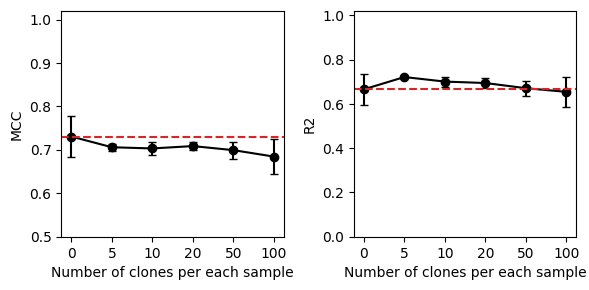

In [33]:
fig, axes = plt.subplots(1,2, figsize=(6,3))

first_ley = list(mcc_for_dupl.keys())[0]

plt.subplot(1, 2, 1)
n_clones = mcc_for_dupl.keys()
mean_arr = [mcc_for_dupl[key][0] for key in mcc_for_dupl.keys()]
std_arr = [mcc_for_dupl[key][1] for key in mcc_for_dupl.keys()]
plt.axhline(y=mcc_for_dupl[first_ley][0], color='tab:red', linestyle='--', linewidth=1.5)
plt.errorbar(range(len(n_clones)), mean_arr, yerr=std_arr, marker='o', capsize=3, linestyle='-', c='black', zorder=-1)

plt.ylim([0.5, 1.02])    
plt.xticks(range(len(n_clones)), n_clones)  
plt.xlabel("Number of clones per each sample")
plt.ylabel("MCC")

plt.subplot(1, 2, 2)
n_clones = r2_for_dupl.keys()
mean_arr = [r2_for_dupl[key][0] for key in r2_for_dupl.keys()]
std_arr = [r2_for_dupl[key][1] for key in r2_for_dupl.keys()]
plt.axhline(y=r2_for_dupl[first_ley][0], color='tab:red', linestyle='--', linewidth=1.5)
plt.errorbar(range(len(n_clones)), mean_arr, yerr=std_arr, marker='o', capsize=3, linestyle='-', c='black', zorder=-1)

plt.ylim([0, 1.02])    
plt.xticks(range(len(n_clones)), n_clones)  
plt.xlabel("Number of clones per each sample")
plt.ylabel("R2")
plt.tight_layout()

plt.show()

## Noize tolerance of the original model

In [11]:
from utils.utils_ancestral_predict import label_ogt_range

use_gpu = torch.cuda.is_available()
tree_method = "gpu_hist" if use_gpu else "hist"
predictor = "gpu_predictor" if use_gpu else "auto"

In [12]:
cog_remov_add_accuracies = defaultdict(dict)

device = DEVICE
cog_removal_rates = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]

noise_std = 0.3
temp_bound = 45

# -----------------------
# Train once per split_id
# -----------------------
trained_models = {}
for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"): #all_splits_dict.keys()
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]


    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    sample_weights = np.array([class_weights[c] for c in range_ids])

    sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
    range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

    # 1. Gating model
    gating_model_with_noise = make_xgb()
    gating_model_with_noise.fit(X_val_train, range_ids, sample_weight=sample_weights)

    # Convert to numpy
    X_train_np = X_val_train.cpu().numpy()
    y_train_np = y_label_train.cpu().numpy().flatten()
    
    # Right and left regressors
    low_mask = y_train_np < temp_bound
    high_mask = y_train_np >= temp_bound

    model_low_with_noise = make_xgb_regressor()
    model_high_with_noise = make_xgb_regressor()
    model_low_with_noise.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_high_with_noise.fit(X_train_np[high_mask], y_train_np[high_mask])

    trained_models[split_id] = (gating_model_with_noise, model_low_with_noise, model_high_with_noise)

Training splits: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [07:06<00:00, 14.20s/it]


In [13]:
from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data_classif_and_regress

cog_remov_add_accuracies_orig_models = eval_trained_models_on_noisy_data_classif_and_regress(trained_models, all_splits_dict, hard_fn_flag = True)

In [14]:
def plot_one_accur_measure(ax, accuracy_measure, cog_remov_add_accuracies, alpha=1):
    cog_remov_add_accuracies_one_measure = defaultdict()
    for key in cog_remov_add_accuracies.keys():
        cog_remov_add_accuracies_one_measure[key] = cog_remov_add_accuracies[key][accuracy_measure]
    
    rem_rates = sorted(set(k[0] for k in cog_remov_add_accuracies_one_measure.keys()))
    add_rates = sorted(set(k[1] for k in cog_remov_add_accuracies_one_measure.keys()))
  #  add_rates = [0.0, 0.05, 0.1]  <------ you can select FP rates for the plot
    
    cmap = plt.cm.tab10
    colors = [cmap(i / (len(rem_rates)-1)) for i in range(len(rem_rates))]

    for i, ar in enumerate(add_rates):
        means = []
        stds = []
        rem_rate_values = []
        for rr in rem_rates:
            key = (rr, ar)
            if key in cog_remov_add_accuracies_one_measure:
                mean, std = cog_remov_add_accuracies_one_measure[key]
                means.append(mean)
                stds.append(std)
                rem_rate_values.append(rr)
        ax.errorbar(rem_rate_values, means, yerr=stds, label = fr"$r_{{FP}}={ar}$", marker='o', capsize=3, linestyle='-', color=colors[i], alpha=alpha)
    
    ax.set_xlabel(r"$r_{FN}$", fontsize=FONTSIZE)
    ax.tick_params(axis='x', labelsize=FONTSIZE)
    ax.tick_params(axis='y', labelsize=FONTSIZE)

In [15]:
# --- output dir ---
if not os.path.exists(f"{OUTPUT_DIRECTORY}/plots"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/plots")

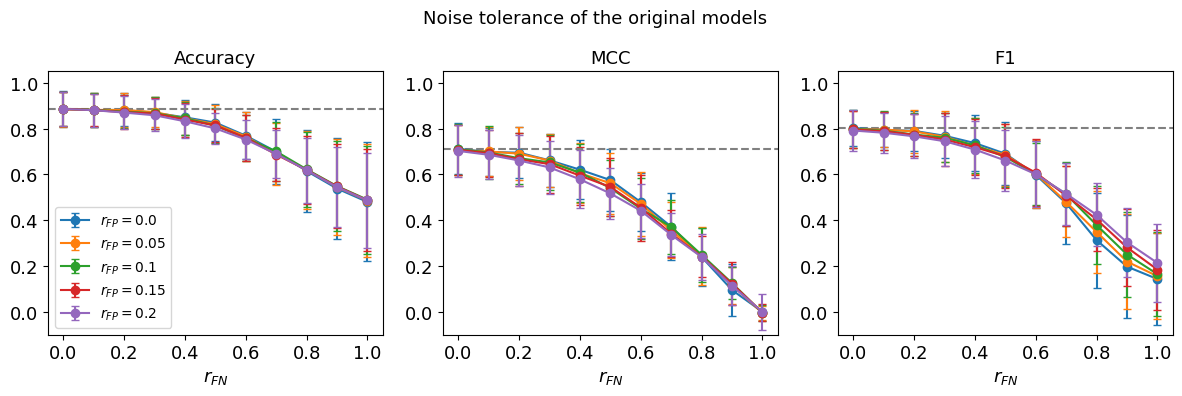

In [16]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

# Accuracy
fig, axes = plt.subplots(1,3, figsize=(12,4))
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Accuracy", fontsize=FONTSIZE)
axes[0].legend()

# MCC
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("MCC", fontsize=FONTSIZE)

# F1
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the original models", fontsize=FONTSIZE)    
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models_classif.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf


In [17]:
cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc']

(np.float64(0.7116120320580255), np.float64(0.11189590291310907))

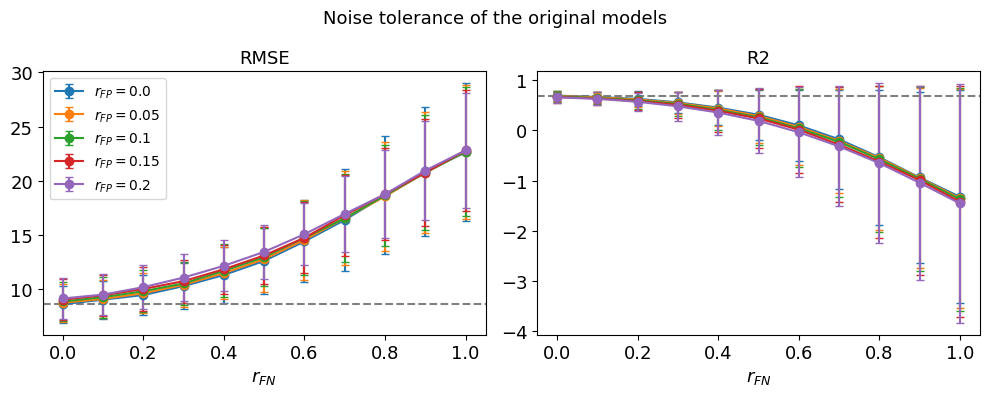

In [18]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,2, figsize=(10,4))
plot_one_accur_measure(axes[0], "rmse", cog_remov_add_accuracies_orig_models)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['rmse'][0], color='grey', linestyle='--', linewidth=1.5)
#axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("RMSE", fontsize=FONTSIZE)
axes[0].legend()

plot_one_accur_measure(axes[1], "r2", cog_remov_add_accuracies_orig_models)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['r2'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_title("R2", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the original models", fontsize=FONTSIZE) 
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models.pdf", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models_regr.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf


## The models trained on the noisy data

In [18]:
def plot_model_groups(noise_increase_accuracy_one_metric, ax, vmin=0.0, vmax=1, cmap="coolwarm", value = "Mean"):
    data = []
    for (fp, fn), (mean, std) in noise_increase_accuracy_one_metric.items():
        data.append([fp, fn, mean, std])
    df = pd.DataFrame(data, columns=["FP", "FN", "Mean", "Std"])
    
    pivot = df.pivot(index="FP", columns="FN", values=value)
    pivot = pivot.astype(float) 
    mask = pivot.isna() 
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, mask=mask, ax=ax, cbar=False)


In [19]:
import seaborn as sns
from utils.utils_ancestral_predict import  read_and_evaluate_models_for_x_and_sigma_regress

Processing noise rates...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 86.73it/s]


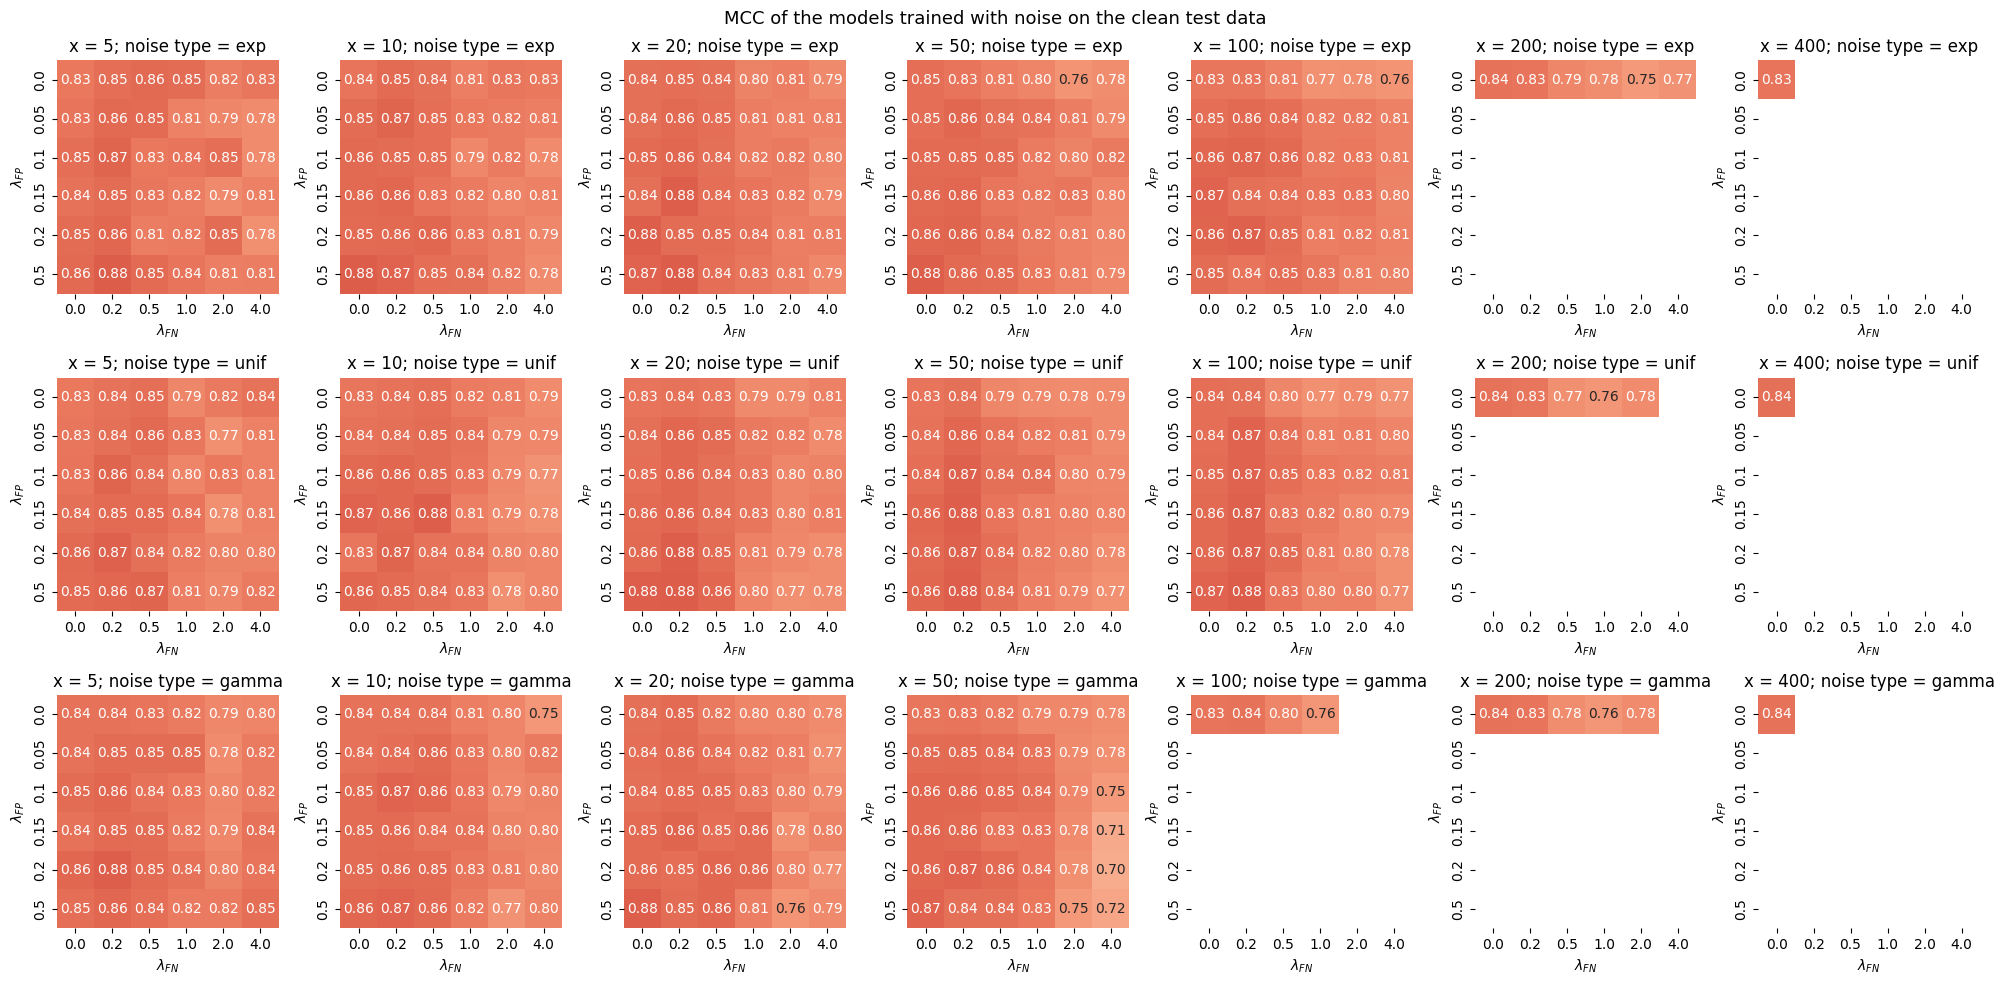

In [20]:
x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'mcc'

FONTSIZE=13

noise_type_range = ["exp", "unif", "gamma"]

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric= read_and_evaluate_models_for_x_and_sigma_regress(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = None, hard_fn_flag = None)
     #   areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(f"MCC of the models trained with noise on the clean test data", fontsize=FONTSIZE)   
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf    

Processing noise rates...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 89.24it/s]


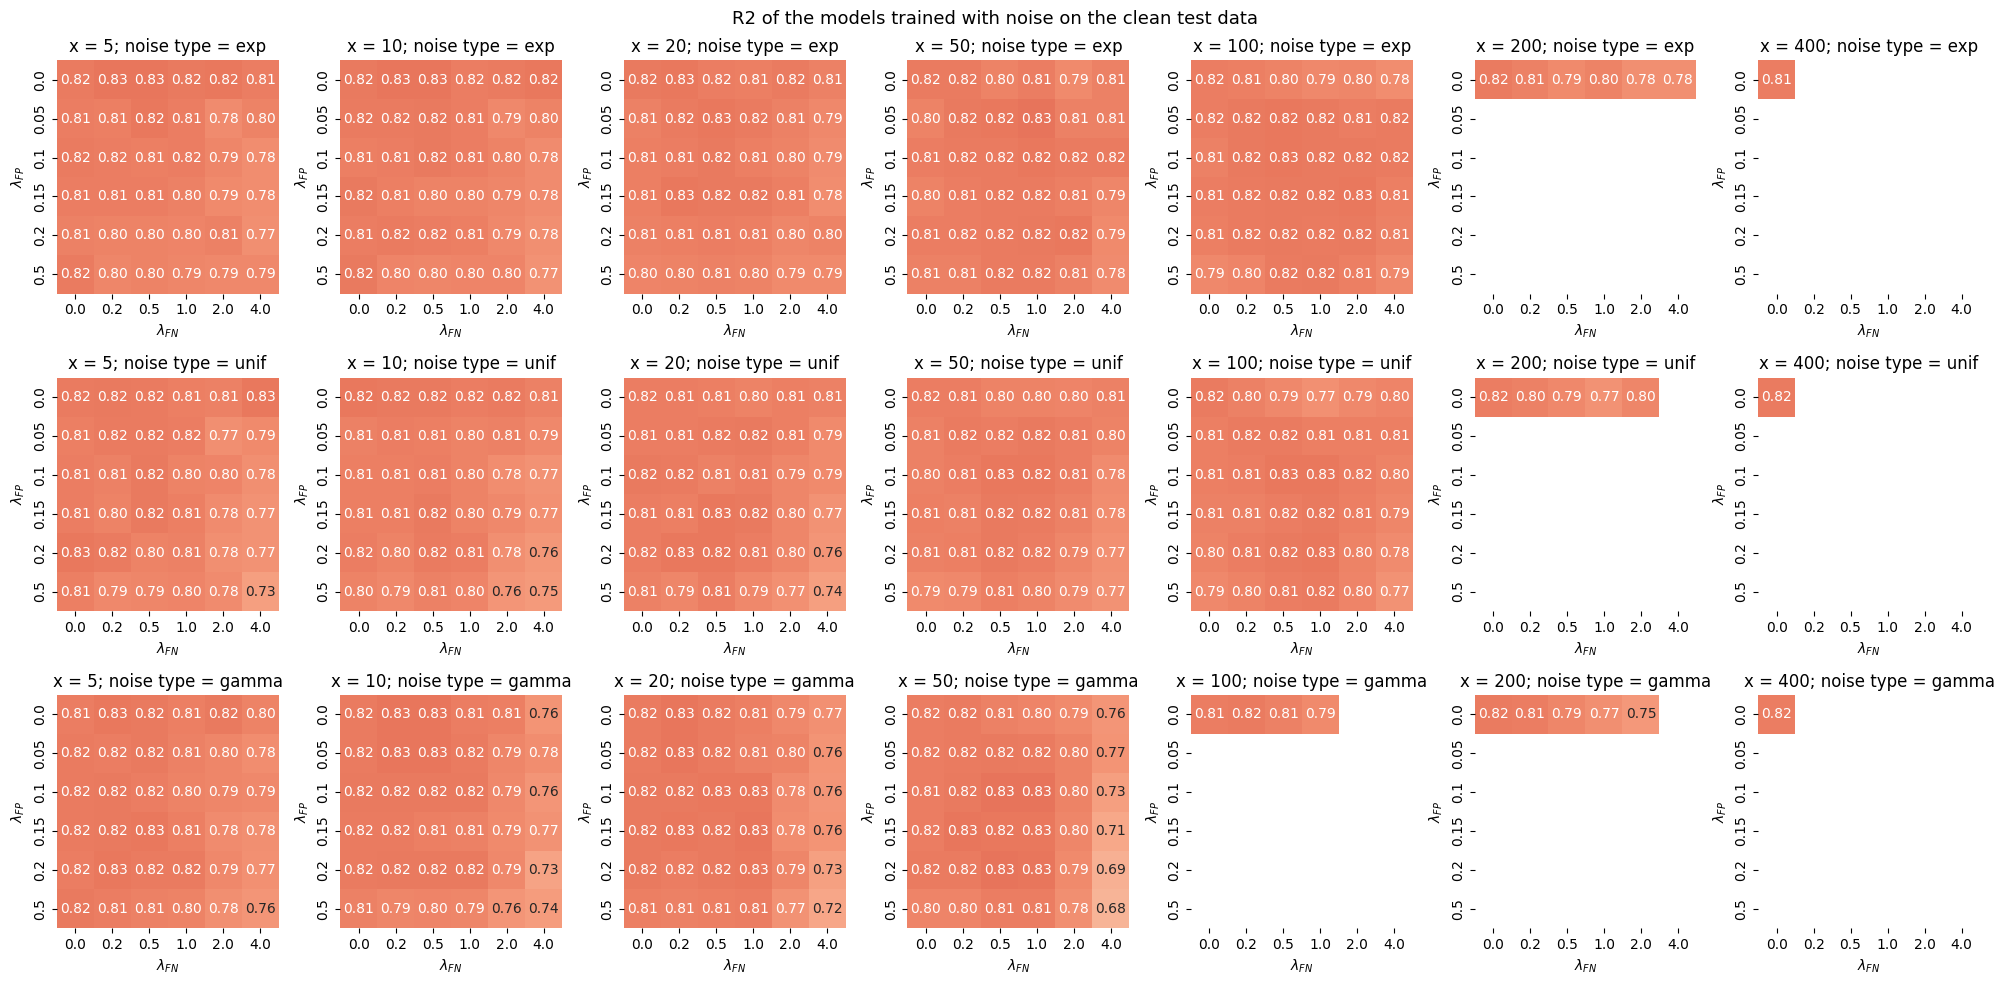

In [21]:
#### from utils.utils_ancestral_predict import  read_and_evaluate_models_for_x_and_sigma_regress

x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'r2'

noise_type_range = ["exp", "unif", "gamma"]

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric= read_and_evaluate_models_for_x_and_sigma_regress(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = None, hard_fn_flag = None)
     #   areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(f"R2 of the models trained with noise on the clean test data", fontsize=FONTSIZE)   
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf    

## Noisy models on noisy data

Processing noise rates...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:01<00:00, 33.51it/s]


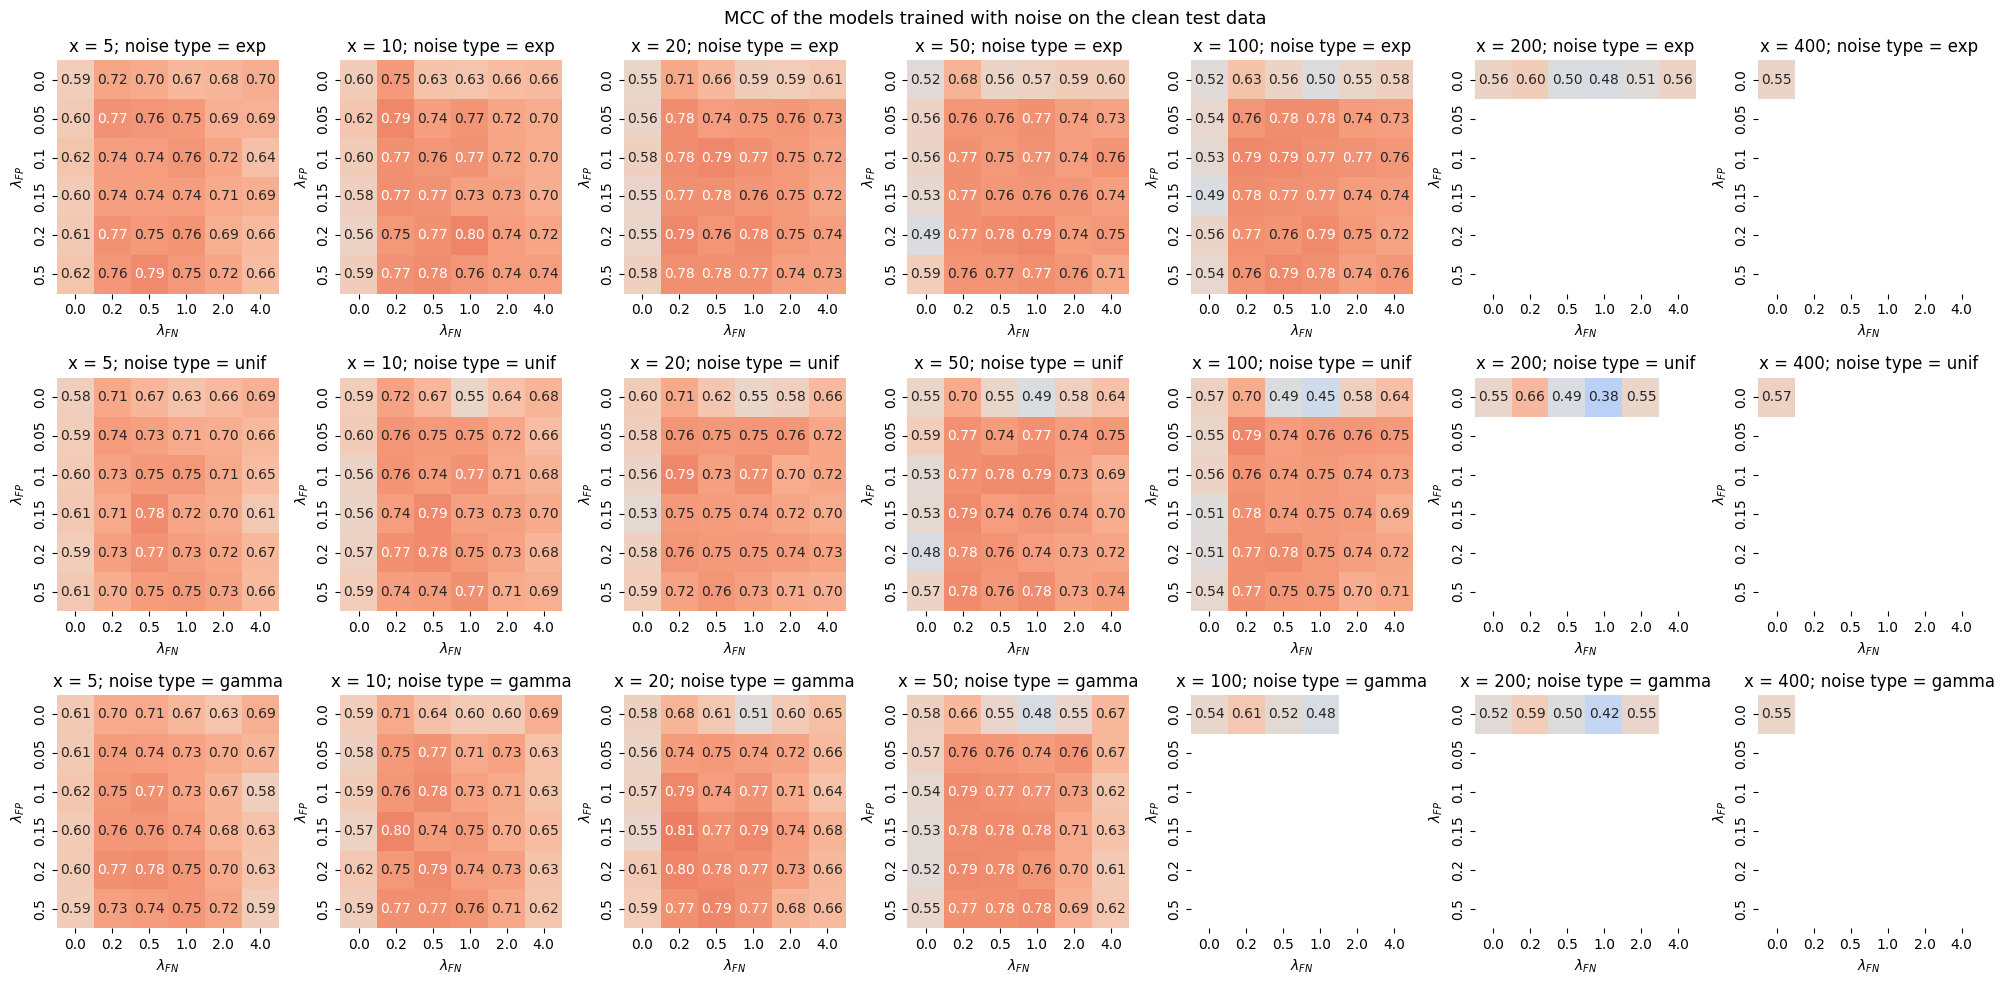

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'mcc'

noise_type_range = ["exp", "unif", "gamma"]

test_fp = 0.1
test_fn = 0.5

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma_regress(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = False, add_rate = test_fp, rem_rate = test_fn, noise_std = 0.3, hard_fn_flag = None)
     #   areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")
        
plt.suptitle(f"MCC of the models trained with noise on the clean test data", fontsize=FONTSIZE)   
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf   

TypeError: read_and_evaluate_models_for_x_and_sigma_regress() missing 2 required positional arguments: 'all_splits_dict' and 'output_directory'

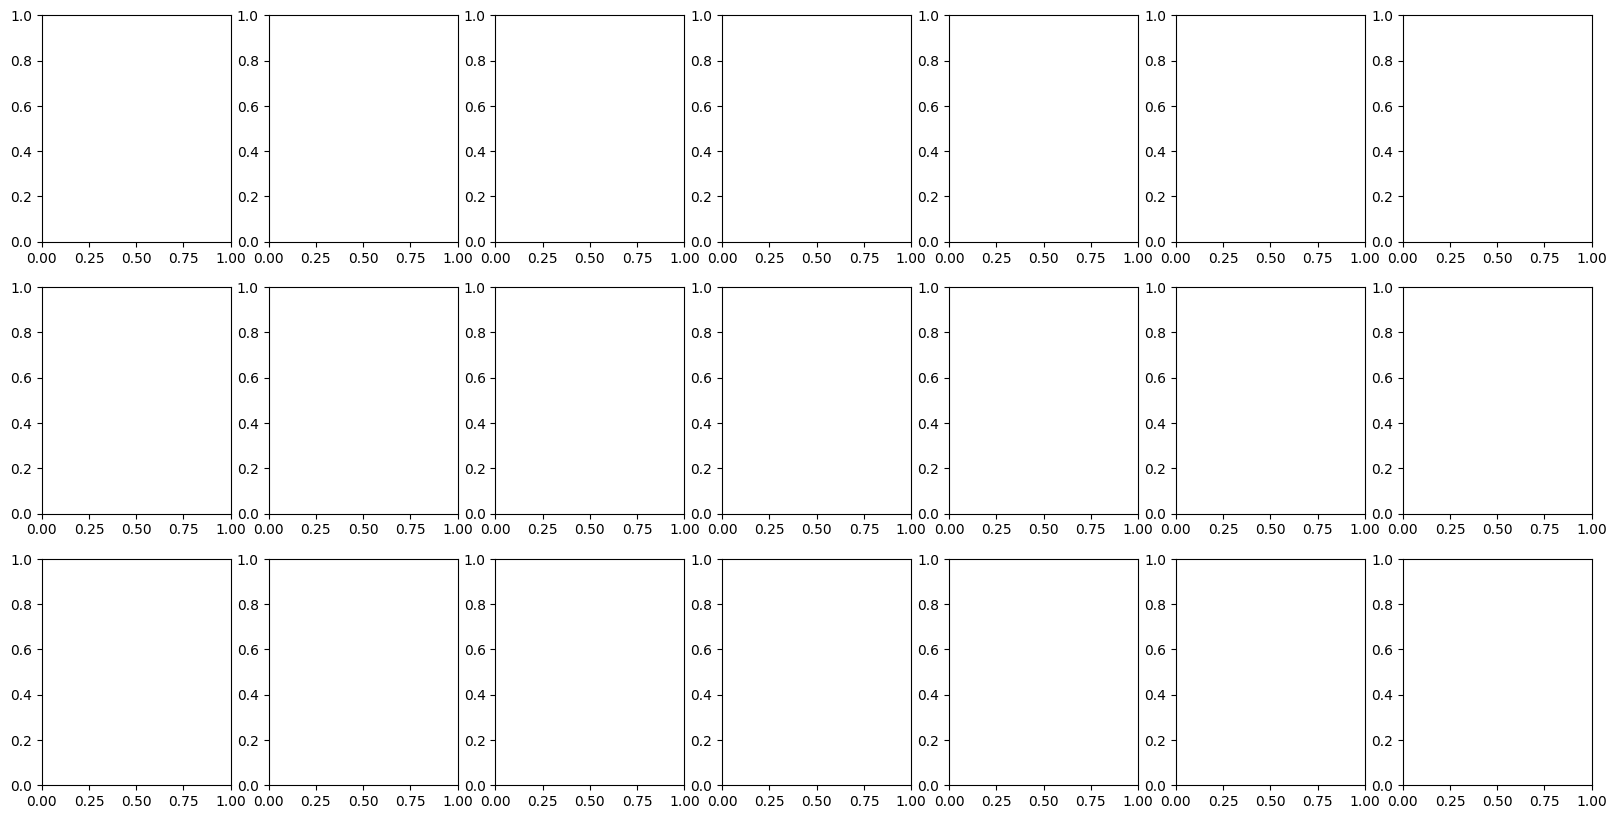

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x_range = [5, 10, 20, 50, 100, 200, 400]
metric = 'r2'

noise_type_range = ["exp", "unif", "gamma"]

test_fp = 0.1
test_fn = 0.5

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma_regress(TRAINED_MOD_DIR, x, noise_type, metric, clean_test_flag = False, add_rate = test_fp, rem_rate = test_fn, noise_std = 0.3, hard_fn_flag = None)
     #   areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")
        
plt.suptitle(f"R2 of the models trained with noise on the clean test data", fontsize=FONTSIZE)   
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf   

### Analyze the performance of the models on the wide noise range [0, max_fp], [0, max_fn]

Processing noise types:   0%|                                                                                                                                            | 0/3 [00:00<?, ?it/s]


TypeError: eval_trained_models_on_noisy_data_classif_and_regress() got an unexpected keyword argument 'min_fp'

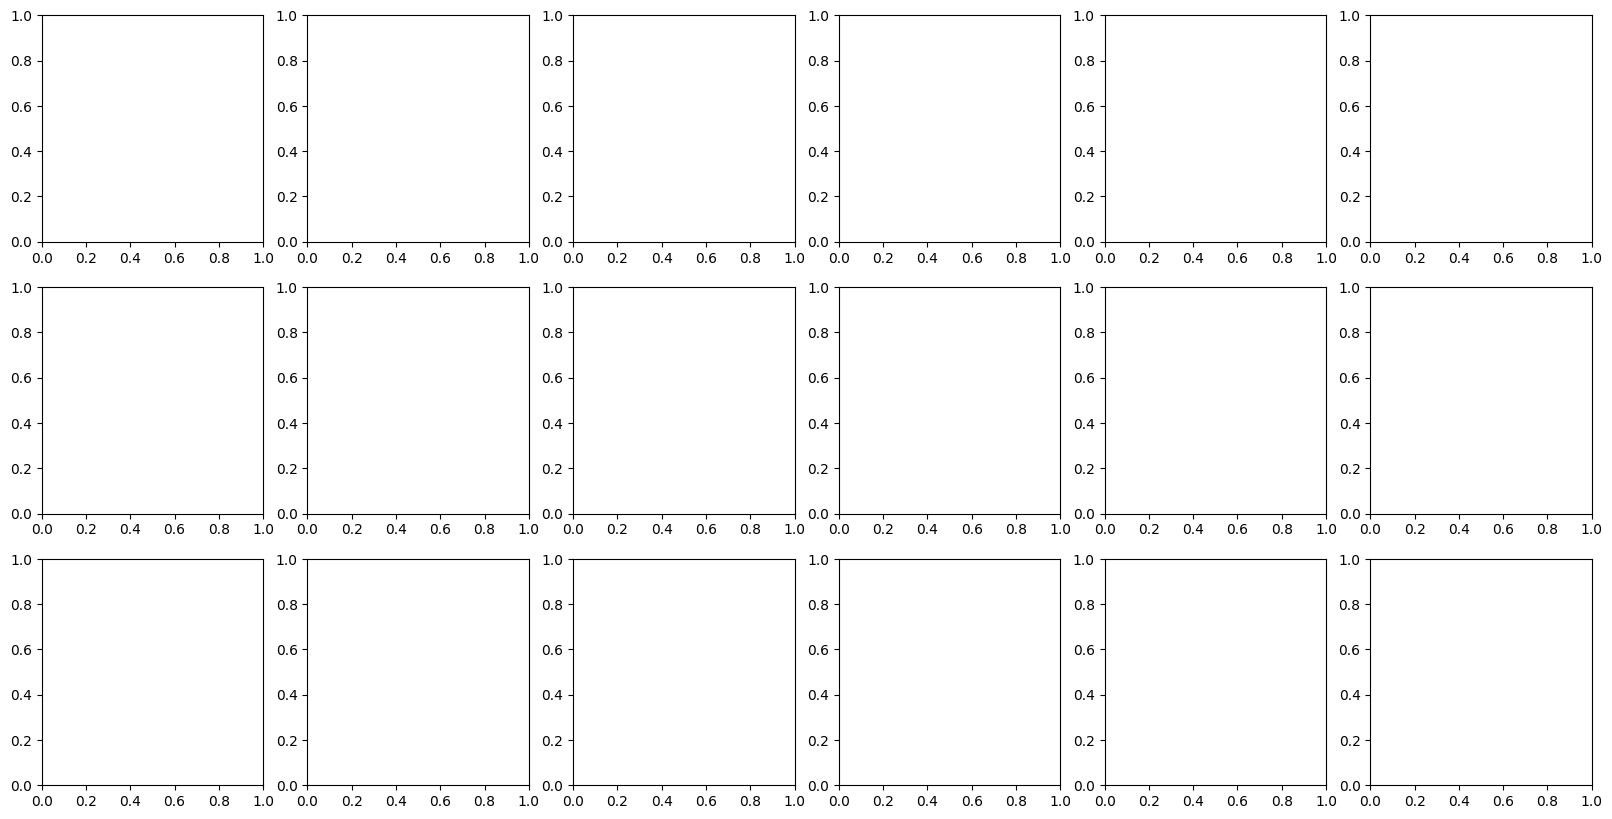

In [23]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data_classif_and_regress, fp_curve_areas_one_model

fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]#[0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]#[0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]
x_range = [5, 10, 20, 50, 100, 200]#, 400]
noise_type_range = ["exp", "unif", "gamma"]

min_fn = 0.3#0.1
max_fn = 0.7#1

min_fp = 0.05#0 
max_fp = 0.15#0.25

FONTSIZE = 13

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict_mcc = f"curve_integrals_mcc_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_mcc = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict_mcc}"

        filename_curve_dict_r2 = f"curve_integrals_r2_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_r2 = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict_r2}"
        
        if os.path.exists(filepath_mcc):
            print("Loading the existing dict...")
            one_accur_dict_mcc = joblib.load(filepath_mcc)
            one_accur_dict_r2 = joblib.load(filepath_r2)
        else:
            one_accur_dict_mcc = defaultdict(list)
            one_accur_dict_r2 = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/trained_models/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(loaded_models_dict, all_splits_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas_mcc = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_mcc[fp_fn_tuple] = [np.mean(fp_curve_areas_mcc), np.std(fp_curve_areas_mcc)]

                metric = 'r2'
                fp_curve_areas_r2 = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_r2[fp_fn_tuple] = [np.mean(fp_curve_areas_r2), np.std(fp_curve_areas_r2)]
            
            joblib.dump(one_accur_dict_mcc, filepath_mcc)
            joblib.dump(one_accur_dict_r2, filepath_r2)
            print("Saving the dict...")

        plot_model_groups(one_accur_dict_mcc, ax, vmin=0.0, vmax=1, cmap="gnuplot", value = "Mean")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC Integral mean for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

Processing noise types:   0%|                                                                               | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|███████████████████████▋                                               | 1/3 [00:03<00:06,  3.45s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|███████████████████████████████████████████████▎                       | 2/3 [00:06<00:03,  3.50s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|███████████████████████████████████████████████████████████████████████| 3/3 [00:10<00:00,  3.67s/it]


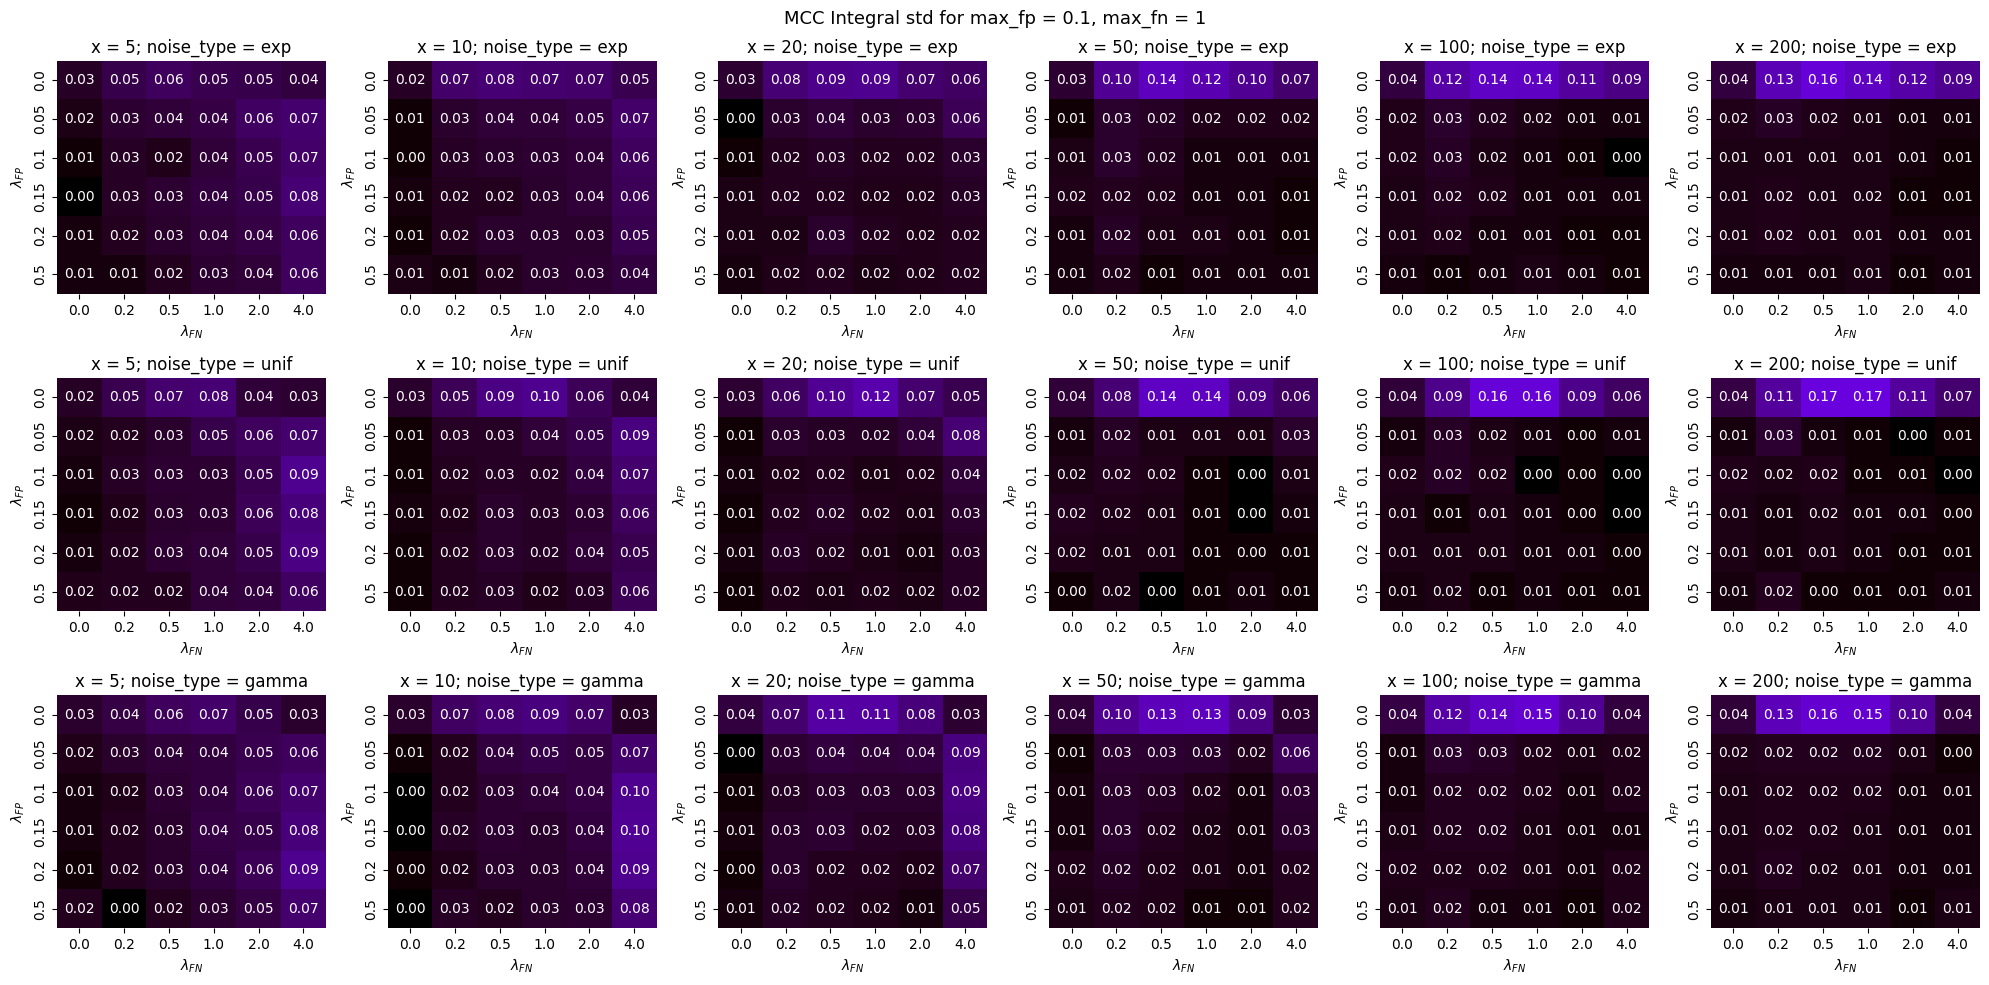

In [12]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data_classif_and_regress, fp_curve_areas_one_model

fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]#[0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]#[0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]
x_range = [5, 10, 20, 50, 100, 200]#, 400]
noise_type_range = ["exp", "unif", "gamma"]

max_fp = 0.1
max_fn = 1

FONTSIZE = 13

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict_mcc = f"curve_integrals_mcc_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_mcc = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict_mcc}"

        filename_curve_dict_r2 = f"curve_integrals_r2_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_r2 = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict_r2}"
        
        if os.path.exists(filepath_mcc):
            print("Loading the existing dict...")
            one_accur_dict_mcc = joblib.load(filepath_mcc)
            one_accur_dict_r2 = joblib.load(filepath_r2)
        else:
            one_accur_dict_mcc = defaultdict(list)
            one_accur_dict_r2 = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(loaded_models_dict, all_splits_dict, hard_fn_flag = True, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas_mcc = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_mcc[fp_fn_tuple] = [np.mean(fp_curve_areas_mcc), np.std(fp_curve_areas_mcc)]

                metric = 'r2'
                fp_curve_areas_r2 = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_r2[fp_fn_tuple] = [np.mean(fp_curve_areas_r2), np.std(fp_curve_areas_r2)]
            
            joblib.dump(one_accur_dict_mcc, filepath_mcc)
            joblib.dump(one_accur_dict_r2, filepath_r2)
            print("Saving the dict...")

        plot_model_groups(one_accur_dict_mcc, ax, vmin=0.0, vmax=1, cmap="gnuplot", value = "Std")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC Integral std for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

Processing noise types:   0%|                                                                               | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|███████████████████████▋                                               | 1/3 [00:02<00:05,  2.92s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|███████████████████████████████████████████████▎                       | 2/3 [00:05<00:02,  2.95s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|███████████████████████████████████████████████████████████████████████| 3/3 [00:10<00:00,  3.35s/it]


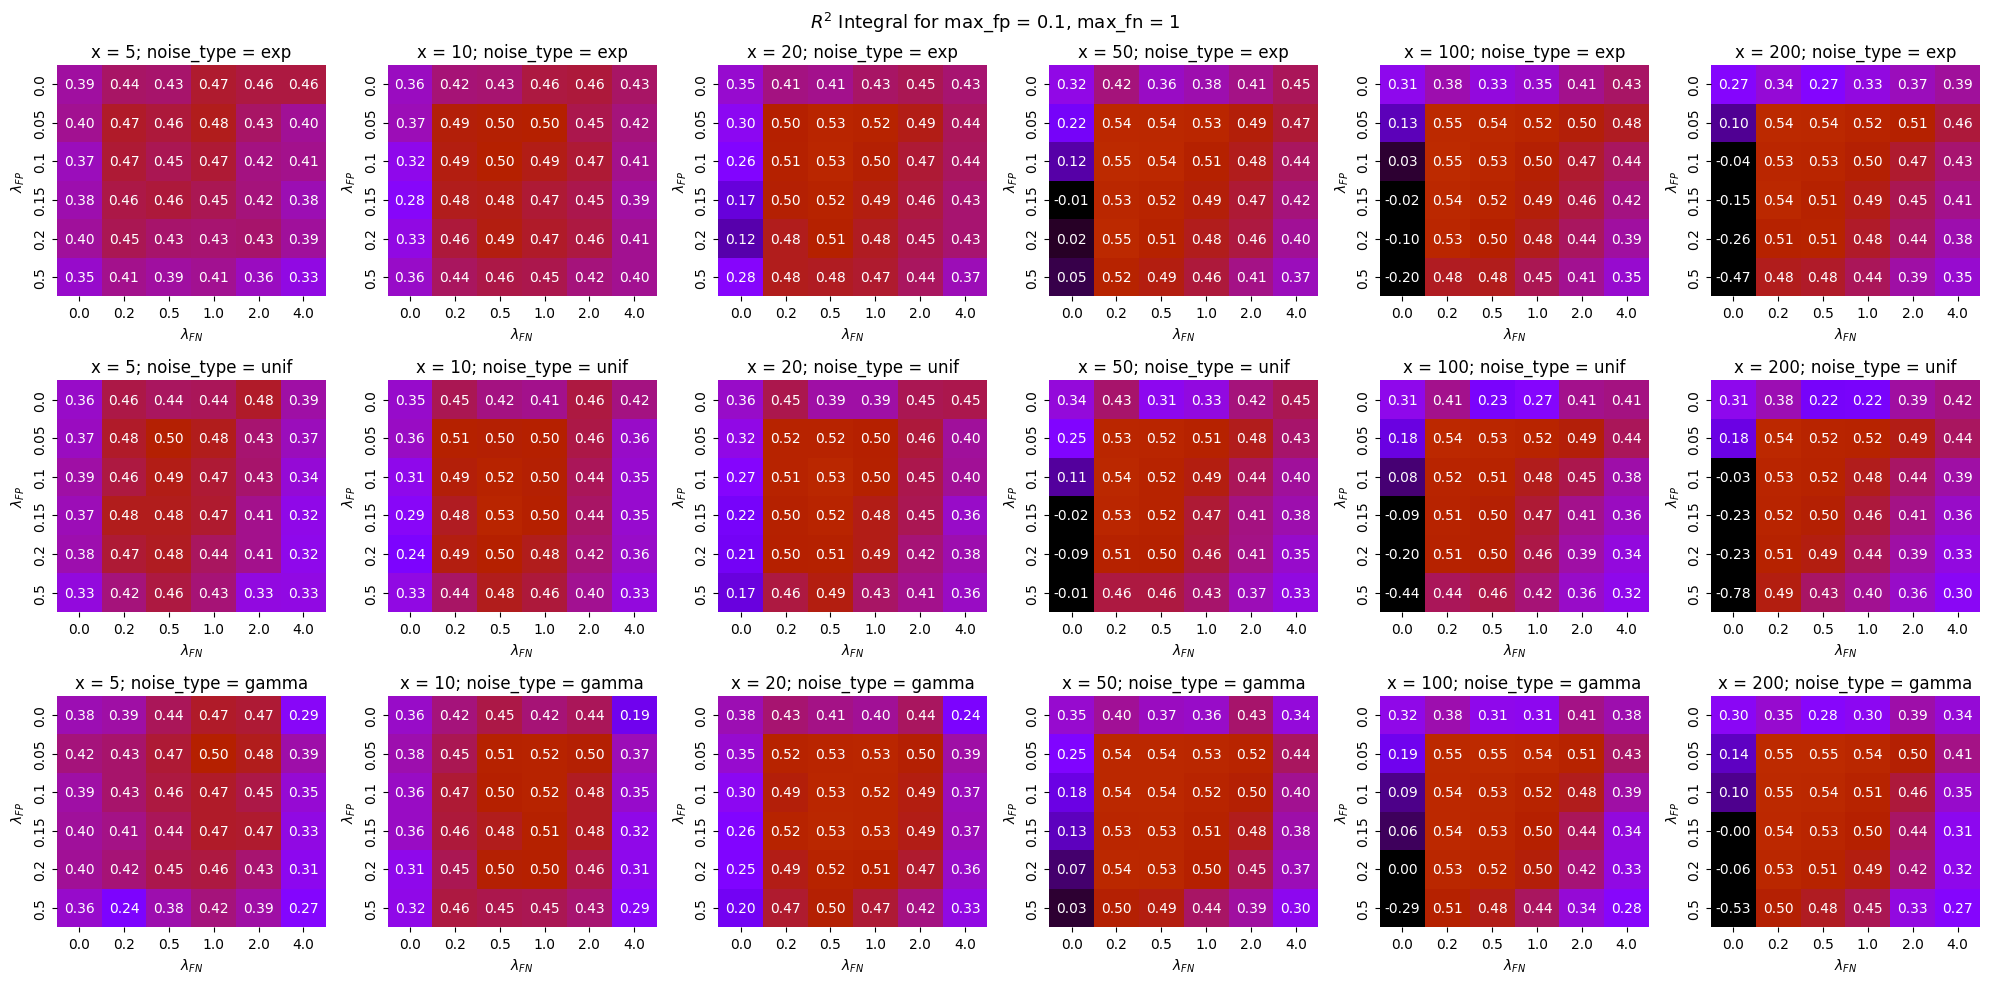

In [13]:
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict_mcc = f"curve_integrals_mcc_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_mcc = f"{OUTPUT_DIRECTORY}/trained_models/{filename_curve_dict_mcc}"

        filename_curve_dict_r2 = f"curve_integrals_r2_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_r2 = f"{OUTPUT_DIRECTORY}/trained_models/{filename_curve_dict_r2}"
        
        if os.path.exists(filepath_mcc):
            print("Loading the existing dict...")
            one_accur_dict_mcc = joblib.load(filepath_mcc)
            one_accur_dict_r2 = joblib.load(filepath_r2)
        else:
            one_accur_dict_mcc = defaultdict(list)
            one_accur_dict_r2 = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/trained_models/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = max_fp, max_fn = max_fn)
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas_mcc = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_mcc[fp_fn_tuple] = [np.mean(fp_curve_areas_mcc), np.std(fp_curve_areas_mcc)]

                metric = 'r2'
                fp_curve_areas_r2 = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_r2[fp_fn_tuple] = [np.mean(fp_curve_areas_r2), np.std(fp_curve_areas_r2)]
            
            joblib.dump(one_accur_dict_mcc, filepath_mcc)
            joblib.dump(one_accur_dict_r2, filepath_r2)
            print("Saving the dict...")

        plot_model_groups(one_accur_dict_r2, ax, vmin=0.0, vmax=1, cmap="gnuplot", value = "Mean")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"$R^2$ Integral for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

Processing noise types:   0%|                                                                               | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|███████████████████████▋                                               | 1/3 [00:02<00:05,  2.99s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|███████████████████████████████████████████████▎                       | 2/3 [00:06<00:03,  3.09s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|███████████████████████████████████████████████████████████████████████| 3/3 [00:10<00:00,  3.33s/it]


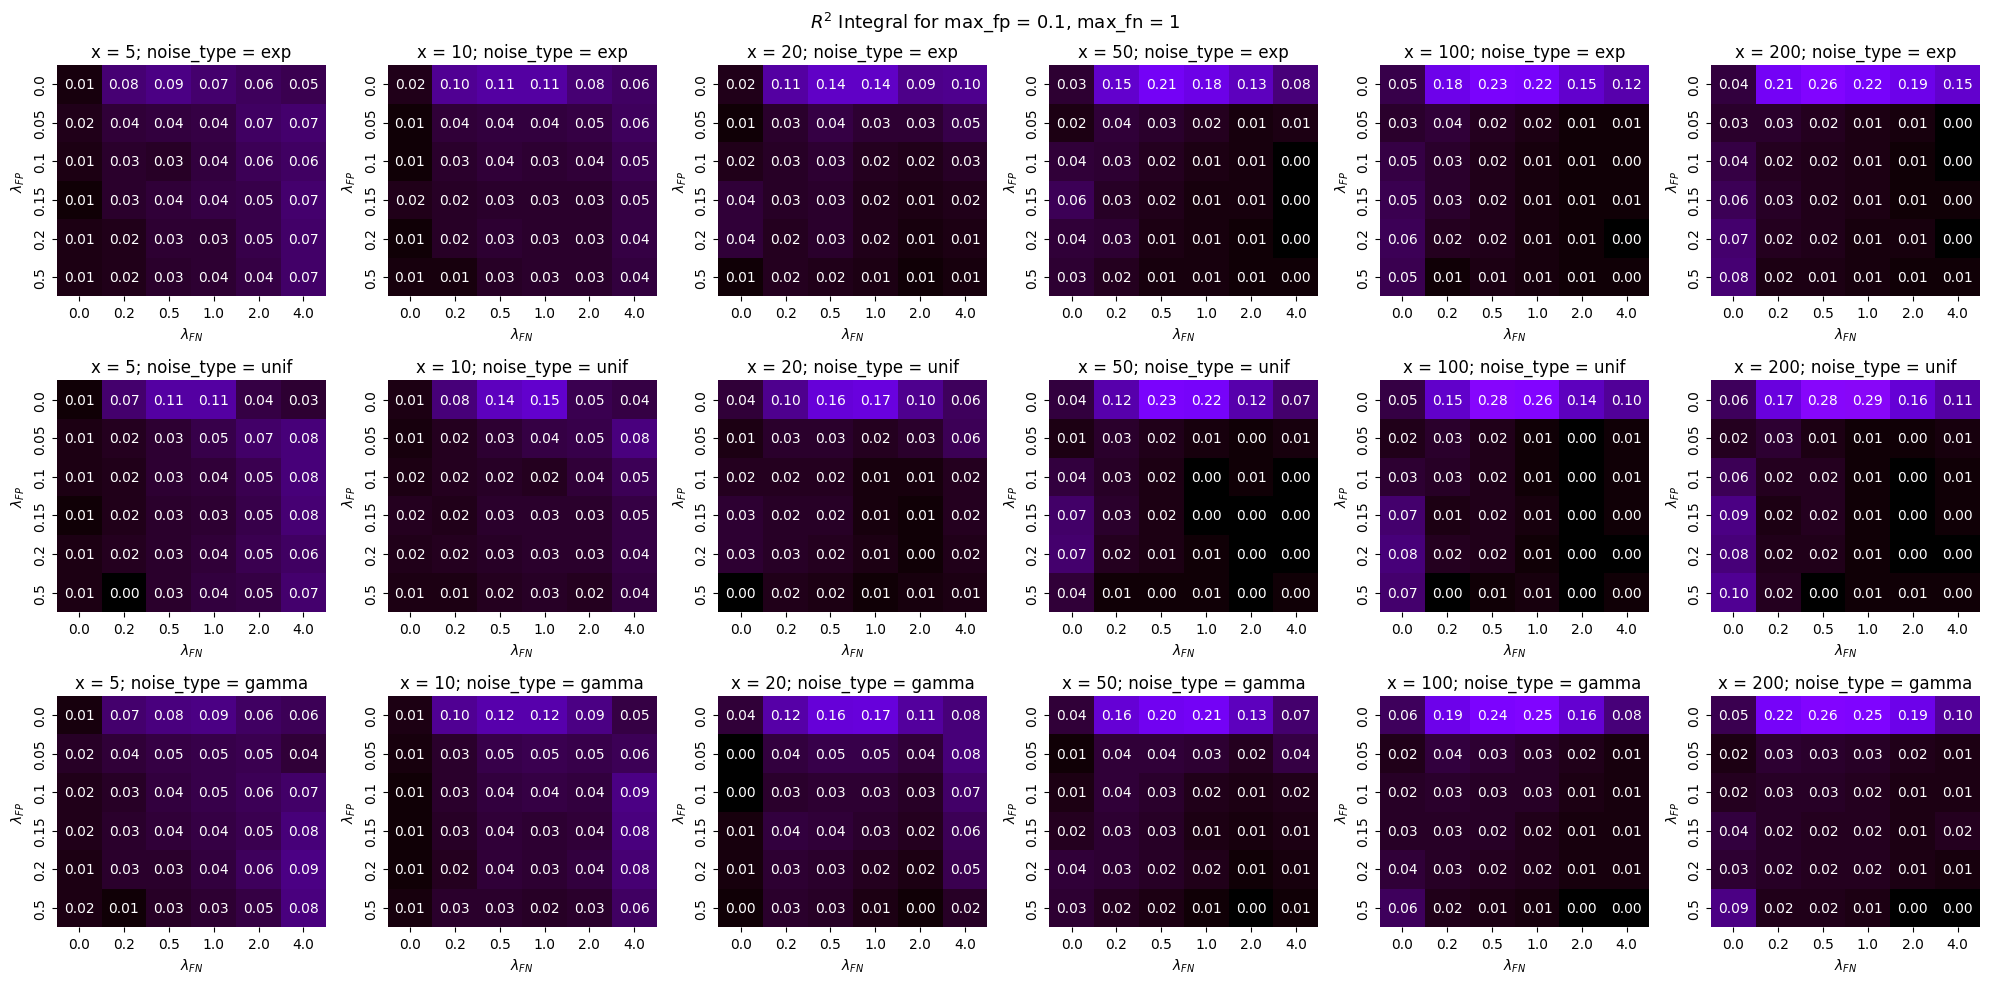

In [14]:
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict_mcc = f"curve_integrals_mcc_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_mcc = f"{OUTPUT_DIRECTORY}/trained_models/{filename_curve_dict_mcc}"

        filename_curve_dict_r2 = f"curve_integrals_r2_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath_r2 = f"{OUTPUT_DIRECTORY}/trained_models/{filename_curve_dict_r2}"
        
        if os.path.exists(filepath_mcc):
            print("Loading the existing dict...")
            one_accur_dict_mcc = joblib.load(filepath_mcc)
            one_accur_dict_r2 = joblib.load(filepath_r2)
        else:
            one_accur_dict_mcc = defaultdict(list)
            one_accur_dict_r2 = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/trained_models/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = max_fp, max_fn = max_fn)
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas_mcc = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_mcc[fp_fn_tuple] = [np.mean(fp_curve_areas_mcc), np.std(fp_curve_areas_mcc)]

                metric = 'r2'
                fp_curve_areas_r2 = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict_r2[fp_fn_tuple] = [np.mean(fp_curve_areas_r2), np.std(fp_curve_areas_r2)]
            
            joblib.dump(one_accur_dict_mcc, filepath_mcc)
            joblib.dump(one_accur_dict_r2, filepath_r2)
            print("Saving the dict...")

        plot_model_groups(one_accur_dict_r2, ax, vmin=0.0, vmax=1, cmap="gnuplot", value = "Std")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"$R^2$ Integral for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

In [22]:
import numpy as np

def fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies):

    # # collect unique sorted coordinates
    # fn_space = sorted({
    #     fn for (fn, fp) in cog_remov_add_accuracies.keys()
    #     if fn <= max_fn and fp <= max_fp
    # })

    # fp_space = sorted({
    #     fp for (fn, fp) in cog_remov_add_accuracies.keys()
    #     if fn <= max_fn and fp <= max_fp
    # })

    fn_space = sorted({
        fn for (fn, fp) in cog_remov_add_accuracies.keys()
        if fn <= max_fn and fn >= min_fn
    })
    
    fp_space = sorted({
        fp for (fn, fp) in cog_remov_add_accuracies.keys()
        if fp <= max_fp and fp >= min_fp
    })
    
    # build metric surface
    Z = np.zeros((len(fp_space), len(fn_space)))

    for i, fp in enumerate(fp_space):
        for j, fn in enumerate(fn_space):

            Z[i, j] = cog_remov_add_accuracies[(fn, fp)][metric][0]

    # integrate over FN first
    integral_fn = np.trapezoid(Z, x=fn_space, axis=1)

    # then integrate over FP
    integral_2d = np.trapezoid(integral_fn, x=fp_space)

    return integral_2d

In [23]:
def plot_model_groups_surf_int(noise_increase_accuracy_one_metric, ax, vmin=0.0, vmax=1, cmap="coolwarm", value = "Mean"):
    data = []
    for (fp, fn), mean in noise_increase_accuracy_one_metric.items():
        data.append([fp, fn, mean])
    df = pd.DataFrame(data, columns=["FP", "FN", "Mean"])
    
    pivot = df.pivot(index="FP", columns="FN", values=value)
    pivot = pivot.astype(float) 
    pivot = pivot / 0.05#0.2
    mask = pivot.isna() 
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, mask=mask, ax=ax, cbar=False)

In [24]:
min_fn = 0.3#0.1
max_fn = 0.8#1

min_fp = 0.05#0 
max_fp = 0.15#0.25



cog_adding_rates = [fp for fp in [0.0, 0.05, 0.1, 0.15, 0.2] if fp <= max_fp and fp >= min_fp]
cog_removal_rates = [fn for fn in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] if fn <= max_fn and fn >= min_fn]

cog_adding_rates

[0.05, 0.1, 0.15]

In [27]:
loaded_models_dict.keys()

dict_keys([0, 1, 2])

In [28]:
for split_id, models in loaded_models_dict.items():
    X_test = all_splits_dict[split_id]["X_test"]

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Processing noise types:   0%|                                                                                                                                            | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...


Processing noise types:  33%|███████████████████████████████████████████▋                                                                                       | 1/3 [14:48<29:36, 888.36s/it]

Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...


Processing noise types:  67%|██████████████████████████████████████████████████████████████████████████████████████▋                                           | 2/3 [33:00<16:48, 1008.39s/it]

Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...


Processing noise types:  67%|██████████████████████████████████████████████████████████████████████████████████████▋                                           | 2/3 [48:02<24:01, 1441.14s/it]


FileNotFoundError: [Errno 2] No such file or directory: '../data_ogt/outputs/COG_aa/phylum/trained_models_train_val_test/trained_models_fp_0.0_fn_2.0_noise_type_gamma_x_100.pkl'

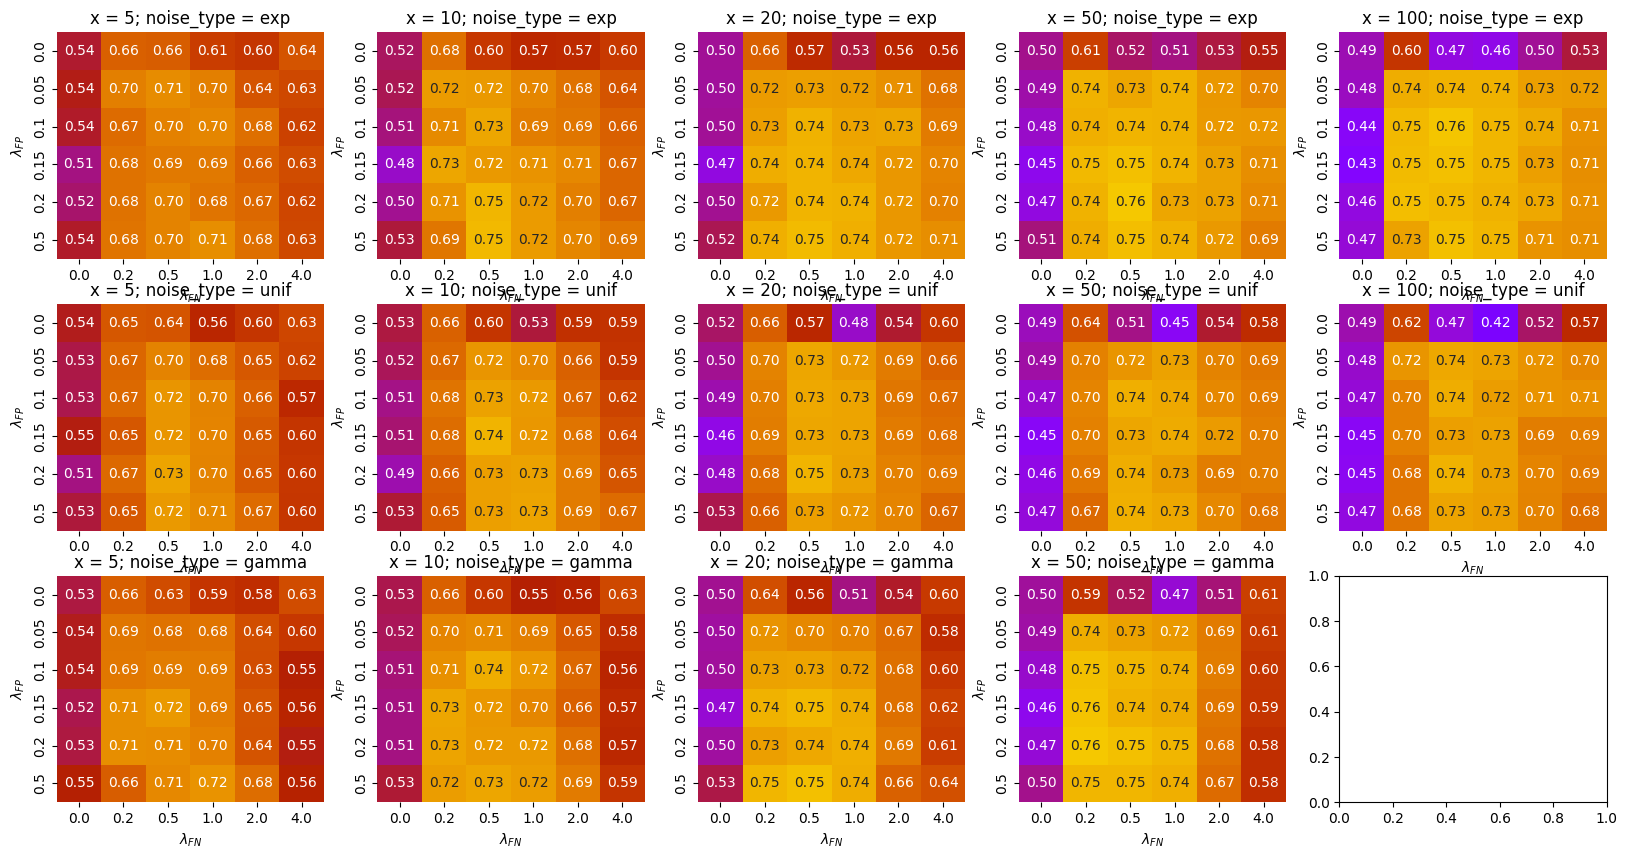

In [32]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data, fp_curve_areas_one_model

fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]#[0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]#[0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]
x_range = [5, 10, 20, 50, 100]#, 200]#, 400]
noise_type_range = ["exp", "unif", "gamma"]

min_fn = 0.3#0.1
max_fn = 0.8#1

min_fp = 0.05#0 
max_fp = 0.15#0.25



FONTSIZE = 13

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"surf_area_integrals_min_fp_{min_fp}_max_fp_{max_fp}_min_fn_{min_fn}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(loaded_models_dict, all_splits_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn)#eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_surface_integral = fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies)#fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)     
                one_accur_dict[fp_fn_tuple] = fp_surface_integral

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups_surf_int(one_accur_dict, ax, vmin=0.3, vmax=0.8, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC Integral mean for min_fp = {min_fp}, max_fp = {max_fp}; min_fn = {min_fn}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

### Visualize the results for the chosen model

In [13]:
# Choose a model
x_noisy_samples = 100
fp_rate_mean = 0.1
fn_rate_mean = 1.0
noise_type = "exp"

filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.pkl"
loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/trained_models/{filename}")

In [14]:
loaded_models_dict.keys()

dict_keys([0, 1, 2])

In [15]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data_classif_and_regress
cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(loaded_models_dict, all_splits_dict, hard_fn_flag = True)

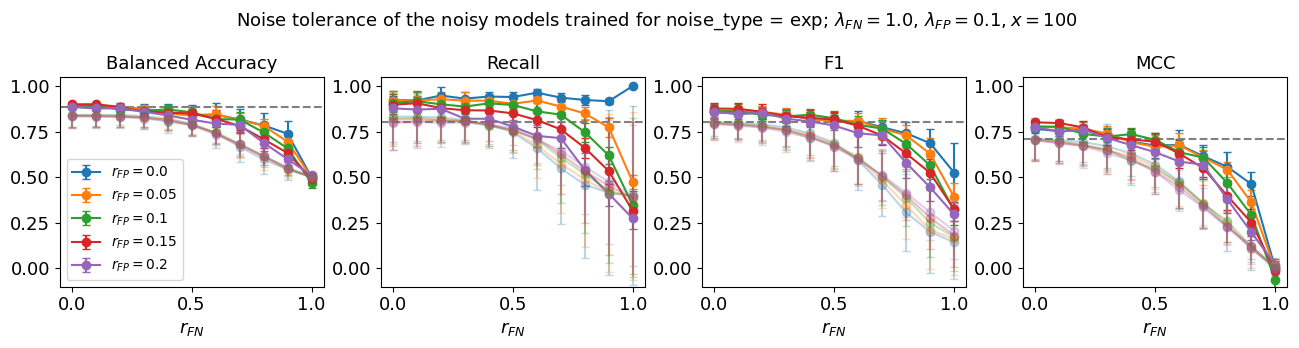

In [16]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,4, figsize=(13,3.5))

plt.subplot(1, 4, 1)
plot_one_accur_measure(axes[0], "balanced_accuracy", cog_remov_add_accuracies)
axes[0].legend()
plot_one_accur_measure(axes[0], "balanced_accuracy", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Balanced Accuracy", fontsize=FONTSIZE)

plt.subplot(1, 4, 2)
plot_one_accur_measure(axes[1], "recall", cog_remov_add_accuracies)
plot_one_accur_measure(axes[1], "recall", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("Recall", fontsize=FONTSIZE)

plt.subplot(1, 4, 3)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)


plt.subplot(1, 4, 4)
plot_one_accur_measure(axes[3], "mcc", cog_remov_add_accuracies)
plot_one_accur_measure(axes[3], "mcc", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[3].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[3].set_ylim([-0.1,1.05])
axes[3].set_title("MCC", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the noisy models trained for noise_type = {noise_type}; $\lambda_{{FN}} = {fn_rate_mean}$, $\lambda_{{FP}} = {fp_rate_mean}, x = {x_noisy_samples}$", fontsize=FONTSIZE)
plt.tight_layout()

metric = "mcc"
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_noisy_model_FP_{fp_rate_mean}_FN_{fn_rate_mean}_x_{x_noisy_samples}_{metric}_classif.svg", format="svg", bbox_inches='tight') #<-------save as pdf

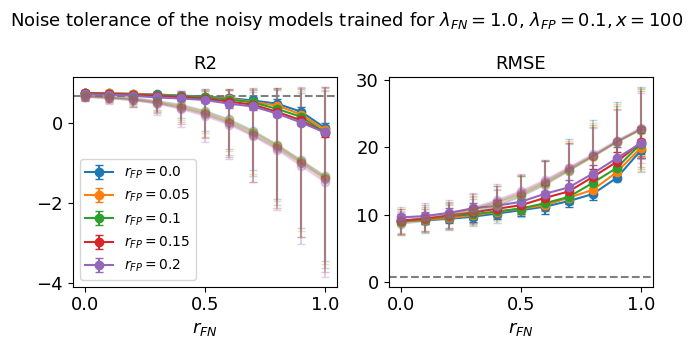

In [17]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,2, figsize=(6.5,3.5))

plt.subplot(1, 2, 1)
plot_one_accur_measure(axes[0], "r2", cog_remov_add_accuracies)
axes[0].legend()
plot_one_accur_measure(axes[0], "r2", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['r2'][0], color='grey', linestyle='--', linewidth=1.5)
#axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("R2", fontsize=FONTSIZE)


plt.subplot(1, 2, 2)
plot_one_accur_measure(axes[1], "rmse", cog_remov_add_accuracies)
plot_one_accur_measure(axes[1], "rmse", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['r2'][0], color='grey', linestyle='--', linewidth=1.5)
#axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("RMSE", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the noisy models trained for $\lambda_{{FN}} = {fn_rate_mean}$, $\lambda_{{FP}} = {fp_rate_mean}, x = {x_noisy_samples}$", fontsize=FONTSIZE)
plt.tight_layout()
metric = "r2"
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_noisy_model_FP_{fp_rate_mean}_FN_{fn_rate_mean}_x_{x_noisy_samples}_{metric}_regress.svg", format="svg", bbox_inches='tight') #<-------save as pdf

In [30]:
f"{OUTPUT_DIRECTORY}/plots/noise_toler_noisy_model_FP_{fp_rate_mean}_FN_{fn_rate_mean}_x_{x_noisy_samples}_{metric}_regress.svg"

'../data_ogt/outputs/COG_aa/phylum/plots/noise_toler_noisy_model_FP_0.1_FN_1.0_x_100_r2_regress.svg'

## Ancestral Data

In [11]:
ogt_annot = pd.read_csv("../data_ogt/ogt_cog_annot.csv", sep=",")
ogt_annot

,accession,ogt
0,GB_GCA_000010565.1,55.0
1,GB_GCA_000016605.1,75.0
2,GB_GCA_000143165.1,31.0
3,GB_GCA_000145985.1,93.5
4,GB_GCA_000161775.1,45.0
...,...,...
3672,RS_GCF_904846415.1,25.0
3673,RS_GCF_904846695.1,19.0
3674,RS_GCF_904846715.1,22.0
3675,RS_GCF_905220995.1,30.0


In [12]:
import polars as pl

BAC_TSV = '../data_preparation/gtdb_files/bac120_metadata_r202.tsv'
ARC_TSV = '../data_preparation/gtdb_files/ar122_metadata_r202.tsv'

tax_level = "phylum"
tax_levels = {"domain": 0, "phylum": 1, "class": 2, "order": 3, "family": 4}

gtdb_df = pl.concat([pl.read_csv(BAC_TSV, separator="\t"),
    pl.read_csv(ARC_TSV, separator="\t")])
gtdb_df = gtdb_df[['accession', "gtdb_taxonomy"]]
for key in tax_levels.keys():
    tax_level = tax_levels[key]
    gtdb_df = gtdb_df.with_columns(pl.col("gtdb_taxonomy").str.split(';').list.get(tax_levels[key]).alias(key))
gtdb_df = gtdb_df.drop("gtdb_taxonomy")
#gtdb_df = gtdb_df[['accession', tax_level]]
gtdb_df = gtdb_df.to_pandas()
gtdb_df

,accession,domain,phylum,class,order,family
0,GB_GCA_000013845.2,d__Bacteria,p__Firmicutes_A,c__Clostridia,o__Clostridiales,f__Clostridiaceae
1,GB_GCA_000016465.1,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Enterobacterales,f__Pasteurellaceae
2,GB_GCA_000024525.1,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Cytophagales,f__Spirosomaceae
3,GB_GCA_000152525.1,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Pseudomonadales,f__Pseudomonadaceae
4,GB_GCA_000172955.1,d__Bacteria,p__Campylobacterota,c__Campylobacteria,o__Campylobacterales,f__Helicobacteraceae
...,...,...,...,...,...,...
258401,RS_GCF_900109065.1,d__Archaea,p__Halobacteriota,c__Halobacteria,o__Halobacteriales,f__Haloferacaceae
258402,RS_GCF_900114585.1,d__Archaea,p__Methanobacteriota,c__Methanobacteria,o__Methanobacteriales,f__Methanobacteriaceae
258403,RS_GCF_900773915.1,d__Archaea,p__Halobacteriota,c__Methanosarcinia,o__Methanosarcinales,f__Methanosarcinaceae
258404,RS_GCF_902384055.1,d__Archaea,p__Methanobacteriota,c__Methanobacteria,o__Methanobacteriales,f__Methanobacteriaceae


In [13]:
leaves_acc_names = pd.read_csv("../ancestral_data/GenomesInfo.csv", sep=",")
columns_to_keep = ['accession', 'ShortCode']
leaves_acc_names = leaves_acc_names[columns_to_keep]
leaves_acc_names

,accession,ShortCode
0,GB_GCA_003599535.1,AABM5X1
1,GB_GCA_005223185.1,AABM5X2
2,GB_GCA_002127415.1,AABM5X3
3,GB_GCA_003598085.1,Abys1
4,GB_GCA_003223555.1,Acid1
...,...,...
1002,GB_GCA_001775395.1,Zixi1
1003,GB_GCA_002791595.1,Zixi2
1004,GB_GCA_003105265.1,Zixi3
1005,GB_GCA_002838945.1,Zixi4


In [14]:
leave_nodes_with_taxonomy = pd.merge(leaves_acc_names, gtdb_df, on="accession", how="inner")
leave_nodes_with_taxonomy

,accession,ShortCode,domain,phylum,class,order,family
0,GB_GCA_003599535.1,AABM5X1,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
1,GB_GCA_005223185.1,AABM5X2,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
2,GB_GCA_002127415.1,AABM5X3,d__Bacteria,p__AABM5-125-24,c__AABM5-125-24,o__AABM5-125-24,f__AABM5-125-24
3,GB_GCA_003598085.1,Abys1,d__Bacteria,p__Abyssubacteria,c__SURF-5,o__SURF-5,f__SURF-5
4,GB_GCA_003223555.1,Acid1,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Fen-336,f__Fen-336
...,...,...,...,...,...,...,...
992,GB_GCA_001775395.1,Zixi1,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UBA10806,f__UBA10806
993,GB_GCA_002791595.1,Zixi2,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UM-FILTER-46-8,f__UM-FILTER-46-8
994,GB_GCA_003105265.1,Zixi3,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__FEB-12
995,GB_GCA_002838945.1,Zixi4,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__PGXB01


In [15]:
df = pd.read_csv('../ancestral_data/MasterTableEvents.tsv', sep='\t', dtype={'column_name': str})
columns_to_keep = ['COG', 'BranchName', 'presence', 'BranchType']
df = df[columns_to_keep]
df['presence'] = (df['presence'] >= 0.5).astype(int)


df_summed = df.groupby(['COG', 'BranchName'])['presence'].sum().reset_index()

pivot_df = df_summed.pivot(index='BranchName', columns='COG', values='presence').fillna(0)
pivot_df.index.name = None
pivot_df.rename(columns={'COG': 'nodes'}, inplace=True)
node_names = pivot_df.index.tolist()
pivot_df

COG,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,COG0010,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
1007,1,0,0,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1008,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1009,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1010,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1011,1,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zixi1,1,0,0,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
Zixi2,1,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,1,1
Zixi3,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Zixi4,1,0,0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,1,0


In [16]:
cogs_from_mastertable = list(pivot_df.columns)
len(cogs_from_mastertable)

2847

In [17]:
cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))
len(cogs_intersect)

2843

In [19]:
#cogs_intersect

with open("my_list.txt", "w") as f:
    for item in my_list:
        f.write(f"{item}\n")

In [20]:
tree_nodes_data = pivot_df[cogs_intersect]
tree_nodes_data

COG,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,COG0010,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
1007,1,0,0,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1008,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1009,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1010,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1011,1,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zixi1,1,0,0,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
Zixi2,1,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,1,1
Zixi3,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Zixi4,1,0,0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,1,0


In [21]:
ogt_cogs = pd.read_csv("../data_ogt/ogt_cog.csv", sep=",")
merged_tab  = pd.merge(ogt_cogs, ogt_annot, on="accession", how="inner") 
merged_tab["ogt_binary"] = np.where(merged_tab["ogt"] > 45, "high", "low")

merged_tab

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,...,COG5658,COG5659,COG5660,COG5661,COG5662,COG5663,COG5664,COG5665,ogt,ogt_binary
0,GB_GCA_000010565.1,1,1,0,1,2,1,1,2,1,...,1,0,0,0,2,1,0,0,55.0,high
1,GB_GCA_000016605.1,1,1,0,3,1,2,2,2,1,...,0,0,0,0,0,0,0,0,75.0,high
2,GB_GCA_000143165.1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,31.0,low
3,GB_GCA_000145985.1,1,1,0,0,0,2,0,2,1,...,0,0,0,0,0,0,0,0,93.5,high
4,GB_GCA_000161775.1,1,1,0,2,1,6,3,3,1,...,0,0,0,0,0,0,0,0,45.0,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3672,RS_GCF_904846415.1,1,1,1,2,1,1,1,3,2,...,0,0,0,0,0,0,0,0,25.0,low
3673,RS_GCF_904846695.1,1,1,1,1,1,1,2,3,2,...,0,0,0,0,0,0,0,0,19.0,low
3674,RS_GCF_904846715.1,1,1,1,1,1,1,2,3,2,...,0,0,0,0,0,0,0,0,22.0,low
3675,RS_GCF_905220995.1,1,1,0,1,1,2,2,2,2,...,0,0,1,0,1,0,0,0,30.0,low


In [22]:
y_label_train_class = torch.tensor(merged_tab["ogt_binary"].map({"high": 1, "low": 0}).to_numpy(), dtype=torch.long)
y_label_train_regr = torch.tensor(merged_tab["ogt"].to_numpy(), dtype=torch.long)

In [23]:
numeric_df = merged_tab.iloc[:, 1:-2]
numeric_values = torch.tensor(numeric_df.values, dtype=torch.float32)
numeric_values = (numeric_values> 0).int()  
numeric_values.shape

torch.Size([3677, 4789])

In [24]:
X_column_names = merged_tab.columns.tolist()[1:-1]
name_to_idx = {name: i for i, name in enumerate(X_column_names)}

cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))
len(cogs_intersect)

2843

In [20]:
with open("cogs_ancestral_reconstruction_ogt.txt", "w") as f:
    for item in cogs_intersect:
        f.write(f"{item}\n")

In [25]:
tree_nodes_data = pivot_df[cogs_intersect]
tree_nodes_data

COG,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,COG0010,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
1007,1,0,0,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1008,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1009,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1010,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1011,1,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zixi1,1,0,0,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
Zixi2,1,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,1,1
Zixi3,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Zixi4,1,0,0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,1,0


In [26]:
# Keep only those in cogs_intersect AND present in X_column_names
keep_indices = [name_to_idx[cog] for cog in cogs_intersect if cog in name_to_idx]

# Filter tensor and column names
X_val_train_filtered = numeric_values[:, keep_indices]
X_column_names_filtered = [X_column_names[i] for i in keep_indices]
X_val_train_filtered.shape

torch.Size([3677, 2843])

# Check the model performance on the truncated feature set

In [27]:
cog_remov_add_accuracies = defaultdict(dict)

device = DEVICE
cog_removal_rates = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]

noise_std = 0.3
temp_bound = 45

# -----------------------
# Train once per split_id
# -----------------------
trained_models_ancestral_feat = {}
for split_id in tqdm(range(3), desc="Training splits"): #all_splits_dict.keys()
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]

    X_column_names =  all_splits_dict[split_id]["feature_names"]
    name_to_idx = {name: i for i, name in enumerate(X_column_names)}
    
    cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
    cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))

    keep_indices = [name_to_idx[cog] for cog in cogs_intersect if cog in name_to_idx]

    X_val_train_filtered = X_val_train[:, keep_indices]

    
    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    sample_weights = np.array([class_weights[c] for c in range_ids])

    sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
    range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

    # 1. Gating model
    gating_model_with_noise = make_xgb()
    gating_model_with_noise.fit(X_val_train_filtered, range_ids, sample_weight=sample_weights)

    # Convert to numpy
    X_train_np = X_val_train_filtered.cpu().numpy()
    y_train_np = y_label_train.cpu().numpy().flatten()
    
    # Right and left regressors
    low_mask = y_train_np < temp_bound
    high_mask = y_train_np >= temp_bound

    model_low_with_noise = make_xgb_regressor()
    model_high_with_noise = make_xgb_regressor()
    model_low_with_noise.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_high_with_noise.fit(X_train_np[high_mask], y_train_np[high_mask])

    trained_models_ancestral_feat[split_id] = (gating_model_with_noise, model_low_with_noise, model_high_with_noise)

Training splits: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:30<00:00, 10.28s/it]


In [29]:
from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data_classif_and_regress

cog_remov_add_accuracies_ancestr_feat_set = eval_trained_models_on_noisy_data_classif_and_regress(trained_models_ancestral_feat, all_splits_dict, hard_fn_flag = True, truncated_feature_set = keep_indices)

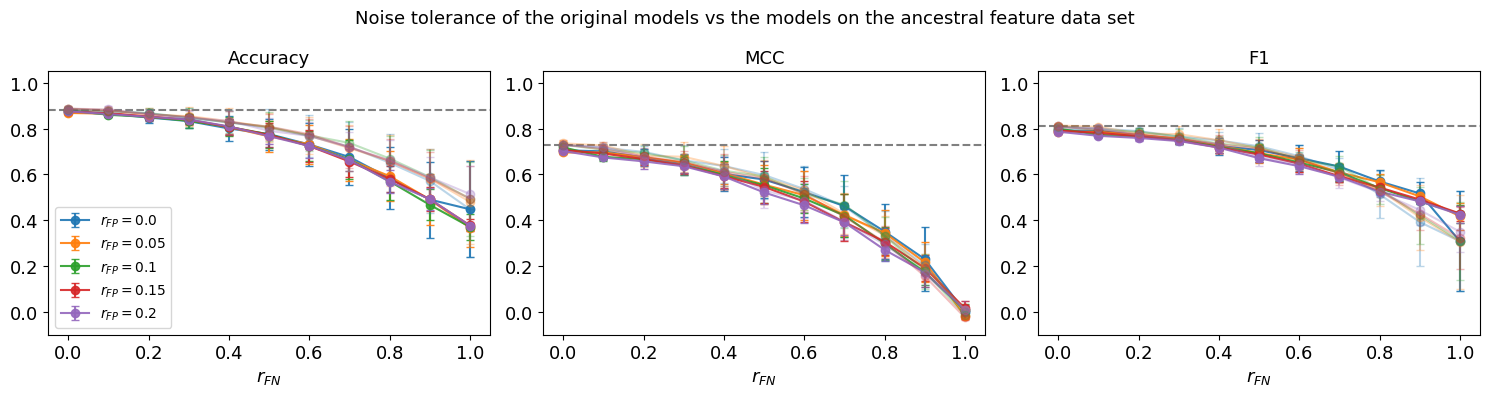

In [35]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,3, figsize=(15,4))

plt.subplot(1, 3, 1)
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_ancestr_feat_set, alpha=0.9)
axes[0].legend()
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Accuracy", fontsize=FONTSIZE)


plt.subplot(1, 3, 2)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_ancestr_feat_set, alpha=0.9)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("MCC", fontsize=FONTSIZE)


plt.subplot(1, 3, 3)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_ancestr_feat_set, alpha=0.9)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the original models vs the models on the ancestral feature data set", fontsize=FONTSIZE)
plt.tight_layout()

metric = "mcc"
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_ancestr_feat_set_classif.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

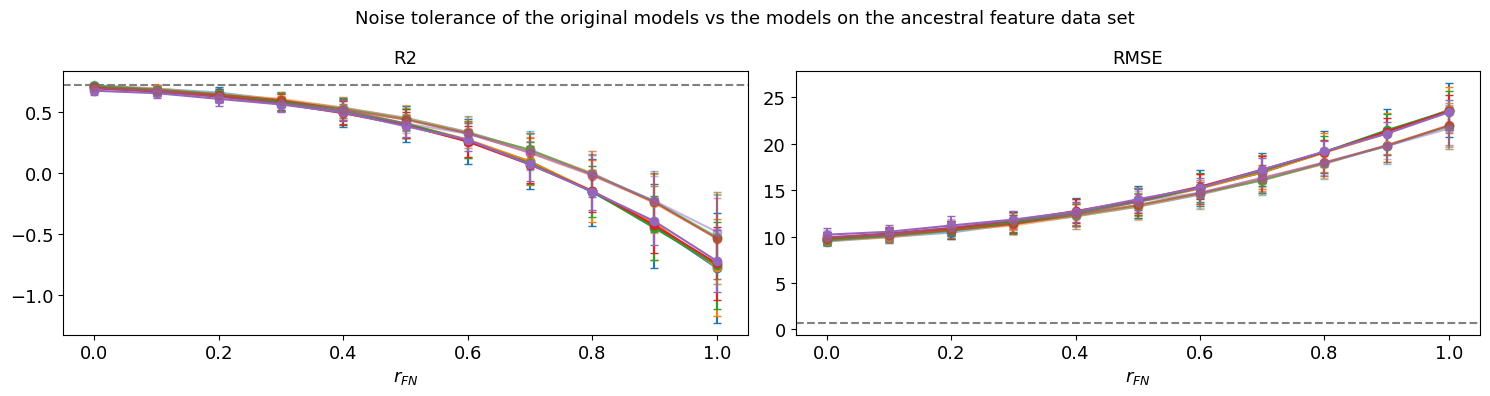

In [36]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,2, figsize=(15,4))

plt.subplot(1, 2, 1)
plot_one_accur_measure(axes[0], "r2", cog_remov_add_accuracies_ancestr_feat_set)
plot_one_accur_measure(axes[0], "r2", cog_remov_add_accuracies_orig_models, alpha=0.5)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['r2'][0], color='grey', linestyle='--', linewidth=1.5)
#axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("R2", fontsize=FONTSIZE)

plt.subplot(1, 2, 2)
plot_one_accur_measure(axes[1], "rmse", cog_remov_add_accuracies_ancestr_feat_set)
plot_one_accur_measure(axes[1], "rmse", cog_remov_add_accuracies_orig_models, alpha=0.5)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['r2'][0], color='grey', linestyle='--', linewidth=1.5)
#axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("RMSE", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the original models vs the models on the ancestral feature data set", fontsize=FONTSIZE)
plt.tight_layout()
metric = "r2"
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_ancestr_feat_set_regrf.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

In [25]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = DEVICE

In [27]:
from utils.utils_ancestral_predict import augment_data_with_noise

# Augment X train with the noise 
x_noisy_samples = 100
fp_rate_mean = 0.1
fn_rate_mean = 1.0
noise_type = "exp"

pipe_with_noise = make_pipeline(make_xgb())

X_augmented, y_augmented = augment_data_with_noise(X_val_train_filtered, y_label_train_regr, x_noisy_samples, fp_rate_mean, fn_rate_mean, noise_type=noise_type, filename=None)

X_augmented.shape

torch.Size([371377, 2843])

In [58]:
# name_to_idx = {name: i for i, name in enumerate(X_column_names)}

# # Keep only those in cogs_intersect AND present in X_column_names
# keep_indices = [name_to_idx[cog] for cog in cogs_intersect if cog in name_to_idx]

# # Filter tensor and column names
# X_val_train_filtered = X_val_train[:, keep_indices]
# X_val_test_filtered = X_val_test[:, keep_indices]
# X_column_names_filtered = [X_column_names[i] for i in keep_indices]
# X_val_test_filtered.shape

In [ ]:
# from utils.utils_ancestral_predict import augment_data_with_noise

# # Augment X train with the noise 
# x = 100
# fp_rate_mean = 0.05
# fn_rate_mean = 0.5
# noise_type = "exp"


# # x_noisy_samples = 100
# # fp_rate_mean = 0.1
# # fn_rate_mean = 1.0
# # noise_type = "exp"

# pipe_with_noise = make_pipeline(make_xgb())

# X_augmented, y_augmented = augment_data_with_noise(X_val_train_filtered, y_label_train, x, fp_rate_mean, fn_rate_mean, noise_type=noise_type, filename=None)
# X_augmented.shape

In [28]:
from sklearn.pipeline import make_pipeline

range_labels = label_ogt_range(y_augmented)
le = LabelEncoder()
range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
label_to_int = {'low': 0, 'high': 1}
range_ids = np.vectorize(label_to_int.get)(range_labels)

classes = np.unique(range_ids)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
class_weights = dict(zip(classes, weights))
sample_weights = np.array([class_weights[c] for c in range_ids])


# Convert to numpy
X_train_np = X_augmented.cpu().numpy()
y_train_np = y_augmented.cpu().numpy().flatten()

sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

# 1. Gating model
classifier = make_xgb()
classifier.fit(X_augmented, range_ids, sample_weight=sample_weights)

# Right and left regressors
temp_bound = 45
low_mask = y_train_np < temp_bound
high_mask = y_train_np >= temp_bound

model_low = make_xgb_regressor()
model_high = make_xgb_regressor()
model_low.fit(X_train_np[low_mask], y_train_np[low_mask])
model_high.fit(X_train_np[high_mask], y_train_np[high_mask])

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [29]:
## Applying to the unseen data
numeric_df = tree_nodes_data.select_dtypes(include=["number"])
ancestral_nodes_tensor = torch.tensor(numeric_df.to_numpy())
ancestral_nodes_tensor.size()

torch.Size([2013, 2843])

In [30]:
y_pred_ancestr_nodes_gating = classifier.predict(ancestral_nodes_tensor.cpu())
y_proba_ancestr_nodes_gating = classifier.predict_proba(ancestral_nodes_tensor.cpu())
max_proba_gating = [max(x) for x in y_proba_ancestr_nodes_gating]

In [31]:
pred_low = model_low.predict(ancestral_nodes_tensor.cpu())
pred_high = model_high.predict(ancestral_nodes_tensor.cpu())
y_pred_ancestr_nodes_final = y_proba_ancestr_nodes_gating[:, 0] * pred_low + y_proba_ancestr_nodes_gating[:, 1] * pred_high

In [32]:
merged_df = pd.merge(ogt_annot, leaves_acc_names, on="accession", how="left")
num_nans = merged_df['ShortCode'].isna().sum()
print(num_nans)
merged_df

3516


,accession,ogt,ShortCode
0,GB_GCA_000010565.1,55.0,NaN
1,GB_GCA_000016605.1,75.0,NaN
2,GB_GCA_000143165.1,31.0,NaN
3,GB_GCA_000145985.1,93.5,NaN
4,GB_GCA_000161775.1,45.0,NaN
...,...,...,...
3672,RS_GCF_904846415.1,25.0,NaN
3673,RS_GCF_904846695.1,19.0,NaN
3674,RS_GCF_904846715.1,22.0,NaN
3675,RS_GCF_905220995.1,30.0,NaN


In [33]:
tree_node_names_list = tree_nodes_data.index.tolist()
print(len(tree_node_names_list))

correct = 0
total = 0

annot_vs_pred_label = []
ogt_gating_arr = []
ogt_final_arr = []
error = []
for idx, node in enumerate(tree_node_names_list):
    if node in list(merged_df['ShortCode']):
        ogt = merged_df.loc[merged_df["ShortCode"] == node, "ogt"]
        ogt_gating_arr.append("high" if ogt.iloc[0]> 45 else "low")
        ogt_final_arr.append(ogt.iloc[0])
        annot_vs_pred_label.append("annot")
        if (ogt.iloc[0] > 45 and y_pred_ancestr_nodes_gating[idx] == 1) or (ogt.iloc[0] < 45 and y_pred_ancestr_nodes_gating[idx] == 0):
            correct += 1
        total +=1   
        error.append((ogt.iloc[0] - y_pred_ancestr_nodes_final[idx])**2)
    else:
        annot_vs_pred_label.append("predict")
        ogt_gating_arr.append("high" if y_pred_ancestr_nodes_gating[idx] == 1 else "low")  #{'low': 0, 'high': 1}
        ogt_final_arr.append(y_pred_ancestr_nodes_final[idx])

df_pred = pd.DataFrame({
    'NodeName': tree_node_names_list,
    'ogt_gating': ogt_gating_arr,
    'ogt_final': ogt_final_arr,
    'annot_or_predict':annot_vs_pred_label,
    'max_proba_gating': max_proba_gating
})

print(f"Correct predict = {correct} of {total}; which is {correct/total}; RMSE = {np.sqrt(np.mean(error))}")
print(f"min pred temp = {np.min(ogt_final_arr)}; max pred temp = {np.max(ogt_final_arr)}")
df_pred



2013
Correct predict = 144 of 161; which is 0.8944099378881988; RMSE = 6.022322263009603
min pred temp = 16.5; max pred temp = 82.293212890625


,NodeName,ogt_gating,ogt_final,annot_or_predict,max_proba_gating
0,1007,high,59.936714,predict,0.984047
1,1008,high,56.556618,predict,0.931405
2,1009,high,52.781582,predict,0.903039
3,1010,high,56.526642,predict,0.853886
4,1011,high,55.038586,predict,0.954141
...,...,...,...,...,...
2008,Zixi1,high,56.014137,predict,0.916975
2009,Zixi2,high,62.675995,predict,0.982466
2010,Zixi3,high,57.409534,predict,0.893873
2011,Zixi4,high,58.477879,predict,0.917600


In [34]:
df_pred.loc[df_pred["NodeName"] == "2012"]

,NodeName,ogt_gating,ogt_final,annot_or_predict,max_proba_gating
1005,2012,high,45.549232,predict,0.526406


In [35]:
uniq_phyl = np.unique(leave_nodes_with_taxonomy["phylum"].values)
phyl_labels = {}
for i in range(len(uniq_phyl)):
    phyl_labels[uniq_phyl[i]] = i    

In [39]:
from Bio import Phylo
from utils.utils_ancestral_predict import process_res


tree = Phylo.read("../ancestral_data/C65.tree", "newick")

cog_name = 'COG1353'
for clade in tree.find_clades(order="level"):
    node_name = clade.name if clade.name is not None else str(clade.confidence)
   # clade.name = node_name
  #  print(node_name)
   # clade.name = node_name
    ogt_gating_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "ogt_gating"])
    ogt_final_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "ogt_final"])
    predict_annot_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "annot_or_predict"])
    max_proba_gating_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "max_proba_gating"])
    max_proba_gating_comm = str(round(float(max_proba_gating_comm), 2)) if max_proba_gating_comm != '' else ''
    cog_count = int(pivot_df.loc[node_name, cog_name]) if cog_name in pivot_df.columns else 0

    tax_comm_phyl = process_res(leave_nodes_with_taxonomy.loc[leave_nodes_with_taxonomy["ShortCode"] == node_name, "phylum"])
    if tax_comm_phyl != '':
        phyl_lab = int(phyl_labels[tax_comm_phyl])
    else:
        phyl_lab = ''

    # if tax_comm_phyl in training_set:
    #     phyl_in_train = 1
    # else:
    #     phyl_in_train = 0
    
    if ogt_gating_comm == "low":
        color = "#1f77b4"  # tab:blue
    else:
        color = "#ff7f0e"  # tab:orange

    clade.comment = f'&!color={color}, ogt_gating={ogt_gating_comm}, ogt_final = {ogt_final_comm}, predict_annot={predict_annot_comm},max_proba_gating={max_proba_gating_comm},{cog_name}={str(cog_count)},phylum={tax_comm_phyl},phyl_label = {phyl_lab}' #,phyl_in_train={phyl_in_train}
    
filename =   f"../ancestral_data/ogt_C65_annotated_on_noisy_train_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.tree"  
Phylo.write(tree, filename, "nexus")
filename

'../ancestral_data/ogt_C65_annotated_on_noisy_train_fp_0.1_fn_1.0_noise_type_exp_x_100.tree'